# UNIVERSITY OF THE FREE STATE
## EDAB2724: Data Analytics for Business
### Assignment 3: Natural Language Processing for Business

**Group number:** `7`

**Group members (name, surname, student number):**

| Name | Surname | Student number |
|---|---|---|
| `Mothae` | `Ntoi` | `2011112980` |
| `Katleho` | `Rathaba` | `2026067146` |
| `Oratile` | `Moletsane` | `2023013242` |
| `Ashley Ashirai` | `Hlatshwayo` | `2025013596` |
| `Mapitso` | `Nyapholi` | `2021327412` |
| `Pascal Jr` | `Bessong` | `2025441375` |

**Assessors:** Dr NE Tamuka, Ms V Oelofse  
**Moderator:** Dr Herkulaas MvE Combrink  
**Due Date:** 6 October 2026  

**Dataset:** Kumari, 2022. *Bitcoin Tweets 2022*. Available at Kaggle.

---


# Part 1: Data Understanding and Audit

## 1.1 Data Audit Table
| Original variable name | New variable name, if renamed | Original data type | New data type, if converted | Description / meaning of the variable |
| :--- | :--- | :--- | :--- | :--- |
| `Tweet Id` | `tweet_id` | object | object | Unique identifier for the tweet. |
| `Tweet URL` | `tweet_url` | object | object | The hyperlink directing to the specific tweet. |
| `Tweet Posted Time` | `tweet_posted_time` | object | datetime64[ns] | The date and time the tweet was published. |
| `Tweet Content` | `tweet_content` | object | object | The raw text of the tweet used as the NLP text corpus. |
| `Tweet Type` | `tweet_type` | object | object | Categorisation of the record as a ReTweet, Tweet, or Reply. |
| `Client` | `client` | object | object | The platform or application used to post the tweet. |
| `Retweets Received` | `retweets_received` | int64 | int64 | The number of retweets received by the tweet. |
| `Likes Received` | `likes_received` | int64 | int64 | The number of likes received by the tweet. |
| `Tweet Location` | `tweet_location` | object | object | The geographical location associated with the tweet/user. |
| `Tweet Language` | `tweet_language` | object | object | The recorded language of the tweet. |
| `User  Id` | `user_id` | object | object | Unique identifier for the user account. |
| `Name` | `name` | object | object | The display name of the user. |
| `Username` | `username` | object | object | The username of the user. |
| `User Bio` | `user_bio` | object | object | The short biography on the user's profile. |
| `Verified or Non-Verified` | `verified_status` | object | object | Indicates whether the account is verified. |
| `Profile URL` | `profile_url` | object | object | Hyperlink to the user's profile. |
| `User Followers` | `user_followers` | float64 | Int64 | Number of users/accounts following the user. |
| `User Following` | `user_following` | float64 | Int64 | Number of accounts the user follows. |
| `User Account Creation Date` | `user_account_creation_date` | object | datetime64[ns] | The date and time the user account was created. |

## 1.2 Import and Standardise Dataset

In [ ]:
from google.colab import files
import pandas as pd

print("Please upload the 'tweets.csv' file:")
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("tweets.csv")

# Standardise all column names to snake_case
def clean_col_name(col):
    return col.strip().replace("  ", " ").replace(" ", "_").lower()

df.columns = [clean_col_name(c) for c in df.columns]
df = df.rename(columns={'verified_or_non-verified': 'verified_status'})

print(f"Initial Dataset: {df.shape[0]} rows and {df.shape[1]} columns.")

Please upload the 'tweets.csv' file:


Saving tweets.csv to tweets.csv
Initial Dataset: 50000 rows and 19 columns.


## 1.3 Data Type Conversions
We parse the date strings into native datetime objects to allow for time-series aggregation later. Follower and following metrics are converted to nullable integers (`Int64`) to safely handle potential missing values without defaulting to floats.

In [ ]:
# Convert both date fields to datetime objects
df["tweet_posted_time"] = pd.to_datetime(df["tweet_posted_time"], errors="coerce")
df["user_account_creation_date"] = pd.to_datetime(df["user_account_creation_date"], errors="coerce")

# Convert user metrics from float64 to Int64 (discrete counts)
df["user_followers"] = df["user_followers"].astype("Int64")
df["user_following"] = df["user_following"].astype("Int64")

print(df[["tweet_posted_time", "user_account_creation_date", "user_followers", "user_following"]].dtypes)

tweet_posted_time             datetime64[ns]
user_account_creation_date    datetime64[ns]
user_followers                         Int64
user_following                         Int64
dtype: object


## 1.4 Dataset Audit (Missing Values, Duplicates, and Scope)

In [ ]:
# Check for duplicates and text completeness
print("Duplicate Tweet IDs:", df["tweet_id"].duplicated().sum())
print("Missing tweet content:", df["tweet_content"].isna().sum())

# Check temporal scope
print("\nEarliest Tweet:", df["tweet_posted_time"].min())
print("Latest Tweet:", df["tweet_posted_time"].max())

# Check composition
print("\nTweet Type Distribution:")
print(df["tweet_type"].value_counts(normalize=True).round(3) * 100)

Duplicate Tweet IDs: 0
Missing tweet content: 0

Earliest Tweet: 2022-09-16 17:33:48
Latest Tweet: 2022-09-17 00:04:53

Tweet Type Distribution:
tweet_type
ReTweet    66.4
Tweet      23.5
Reply      10.0
Name: proportion, dtype: float64


### Key Audit Findings:
1. **Corpus Completeness:** The core NLP target (`tweet_content`) has zero missing values, providing a complete 50,000-row text corpus.
2. **Unique Identifiers:** There are no duplicate `tweet_id` entries, indicating a clean data scrape.
3. **Narrow Temporal Window:** The entire dataset spans an incredibly narrow window of approximately **6.5 hours** on September 16-17, 2022. Hourly time-series visualisations will be restricted to this specific interval.
4. **Retweet Dominance:** Retweets account for **66.4%** of the dataset. Preprocessing will need to aggressively handle RT tags, duplicate texts, and user mentions to prevent the topic model from being skewed by a few viral, heavily-retweeted posts.

## 1.5 Final Modelling Dataset
We isolate the core NLP fields while intentionally retaining engagement metrics (`likes_received`, `retweets_received`, `user_followers`) to support the supplementary business visualisations required during exploratory data analysis.

In [ ]:
# Create the initial modelling dataset with retained engagement metadata
model_df = df[
    [
        "tweet_id",
        "tweet_posted_time",
        "tweet_content",
        "tweet_type",
        "tweet_language",
        "likes_received",
        "retweets_received",
        "user_followers"
    ]
].copy()

model_df = model_df.rename(columns={
    "tweet_posted_time": "datetime",
    "tweet_content": "text"
})

print(f"Modelling dataset shape: {model_df.shape}")
model_df.head()

Modelling dataset shape: (50000, 8)


,tweet_id,datetime,text,tweet_type,tweet_language,likes_received,retweets_received,user_followers
0,"""1570926731019825152""",2022-09-17 00:04:53,"""أدعم التغريدات وفضّلها وأنشرها🙏🏻\n\n🚨سلسلة |#...",ReTweet,Arabic,0,0,169
1,"""1570926731183423488""",2022-09-17 00:04:53,"""💧 Unidef Airdrop 💧\n\n🏆 Task: ➕ $9 ...",ReTweet,English,0,0,38
2,"""1570926713571520513""",2022-09-17 00:04:49,"""Etheruem has officially merged and moved towa...",ReTweet,English,0,0,128
3,"""1570926715228295175""",2022-09-17 00:04:49,"""New airdrop: Kingdomverse (USDT)\nTotal Rewar...",ReTweet,English,0,0,37
4,"""1570926708165050370""",2022-09-17 00:04:48,"""Bitcoin price just went down by $23! Current ...",Tweet,English,1,0,308


Part 2: Text Cleaning and Pre-processing

---
# Part 2: Text Cleaning and Pre-processing

**Goal:** turn the raw tweets in `model_df` into a clean, English-only, non-offensive, de-duplicated corpus that a topic model can learn from.

**Method:** the pre-processing pipeline follows the GeeksforGeeks tutorial *Text Preprocessing in NLP* (https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/), which is linked from the NLP tutorial index. Its steps are: (1) text cleaning with regular expressions, (2) tokenization, (3) stop-word removal, (4) stemming, (5) lemmatization, (6) contractions expansion, (7) emoji conversion (implemented and audited, then switched off), (8) spell correction. We implement each step with the same libraries (`re`, `BeautifulSoup`, NLTK, `contractions`, `emoji`, `pyspellchecker`). Because the tutorial is generic and this is a *tweet topic-modelling* task, we added tweet-specific steps (language filter, retweets, mentions, hashtags, duplicates, offensive content) and, for each tutorial step, decided whether to **apply** it and justified the decision.

Domain terms (`bitcoin`, `btc`, `bullish`, `bearish`, `mining`, `trading`, `price`, `volatility`) are **never** treated as stop words.

## 2.1 Cleaning decisions table

| Cleaning / preprocessing item | What action did we take? | Why did we make this decision? |
| :--- | :--- | :--- |
| **Missing or blank tweet text** | **Removed.** Surrounding quote characters (`"..."`) and whitespace were stripped first, then rows with empty text (or an unparseable timestamp) were dropped. | No rows were affected in this dataset, but the check guards the pipeline. A tweet with no text carries no topic information, and a missing timestamp cannot be placed in the hourly analysis. The raw CSV wraps every field in literal quotes, so blank detection had to happen *after* stripping them. |
| **Duplicate tweets** | **Removed in two passes.** (1) Exact duplicates of the raw text were dropped. (2) After cleaning, tweets with identical *cleaned* text were dropped too (this catches bot templates that differ only by a link, number or mention). | Duplicates were a very large share of the corpus: 937 exact duplicates and a further 5,462 near-duplicates were removed (bot airdrop/price-alert templates). If kept, LDA/NMF would spend most topics modelling a handful of templates rather than genuine discussion. |
| **URLs** | **Removed** with the tutorial's URL regex (any text starting with `http` or `www`). | About 58% of the raw tweets contain a link. `t.co` links are random shortened strings with no semantic content; they would become high-frequency meaningless tokens. |
| **User mentions (@username)** | **Removed** (`@\w+`). This is an addition to the tutorial. | About 30% of the raw tweets contain a mention. Usernames are identifiers, not topics. Punctuation removal alone would leave the username behind as a word, and topics could then form around who is tagged (e.g. giveaway tag-lists). |
| **Emojis** | **Removed** (replaced by a space). The tutorial's `emoji.demojize` conversion was implemented and audited, but is switched off (`EMOJI_MODE = "remove"`). | Converting emojis injects generic descriptor words (`police car light`, `backhand index pointing right`, `face`) that are decoration in promotional tweets, not Bitcoin topics, and they polluted the top of the vocabulary in our test. Removal loses some sentiment cues, which is acceptable because the task is topic discovery, not sentiment. |
| **Retweets** | **Removed** (`tweet_type == "ReTweet"` or text starting with `RT @`). Original tweets and replies are retained. | A retweet is a verbatim copy of someone else's post, so keeping it would count one message many times and let a few viral posts dominate the topics. Retweets were ~66% of the raw data (20,530 English retweets removed). |
| **Hashtags** | **Retained as words** (punctuation removal strips the `#` symbol, so `#Bitcoin` becomes `bitcoin`). The list of hashtags is also saved in a separate `hashtags` column. | About 96% of the raw tweets contain a hashtag. Hashtags are deliberate topic labels chosen by the author and are among the most informative tokens in tweets. The separate column supports the hashtag word cloud in Part 3. |
| **Upper- and lowercase text** | **Converted to lowercase** (`text.lower()`, tutorial step 2). | Prevents `Bitcoin`, `BITCOIN` and `bitcoin` from being counted as three different features. |
| **Special characters** | **Removed** (tutorial step 2): HTML tags/entities via `BeautifulSoup` (`&amp;` becomes `&`), digits (`\d+`), punctuation (`string.punctuation`), other non-word characters (`\W+`) and extra spaces (`\s+`). We replace punctuation with a space rather than deleting it, so `on-chain` becomes `on chain` instead of `onchain`. Non-Latin characters are dropped. | Punctuation and symbols add sparse, non-informative features. Numbers (prices, amounts) vary tweet-to-tweet and fragment the vocabulary; the topic of a tweet is carried by its words. |
| **Tokenization** | **Applied** with NLTK `word_tokenize` (tutorial step 3). | Splits each cleaned tweet into words, which is needed before stop-word removal, stemming, lemmatisation and POS tagging. |
| **Contractions** | **Expanded** with `contractions.fix` (tutorial step 7), e.g. `can't` becomes `cannot`, `don't` becomes `do not`. | If left as-is, punctuation removal would turn `don't` into `don` and `t`, leaving fragments that the stop-word list does not catch. |
| **Stop words** | **Removed**: NLTK English list (tutorial step 4) plus a small custom list of Twitter filler (`amp`, `rt`, `via`, `get`, `like`, `just`, `new`, `today`, ...). Tokens shorter than 3 letters were also dropped. | Stop words are the most frequent words but say nothing about topic; they would appear at the top of every topic. Bitcoin domain terms are explicitly **kept**. |
| **Stemming** | **Computed and compared, but not used** in the final corpus (Porter stemmer, tutorial step 5). | Stemming cuts words to non-words (`volatility` becomes `volatil`, `people` becomes `peopl`), which makes topic keywords hard to read. Interpretability is a core assessment criterion, so we use lemmas. |
| **Lemmatisation** | **Applied** (`WordNetLemmatizer`, tutorial step 6), guided by POS tags (tutorial step 10). | Merges inflections (`prices` becomes `price`, `coins` becomes `coin`, `buying` becomes `buy`) into real dictionary words, shrinking the vocabulary without harming readability. The tutorial lemmatises every word as a noun; we pass the POS tag so verbs and adjectives are lemmatised correctly. |
| **Spell correction** | **Tested, not applied** (`pyspellchecker`, tutorial step 9). | The checker does not know crypto vocabulary and "corrects" domain words into wrong ones (see the demonstration in 2.7), which would destroy the exact terms the assignment tells us to keep. It is also slow on thousands of tweets. |
| **Other: language filter** | **Kept English only** (`tweet_language == "English"`). | Turkish, Arabic, Spanish etc. make up about a third of the data (16,485 tweets removed). English stop-word lists and lemmatisers cannot process them, and mixing languages produces language-based rather than theme-based topics. |
| **Other: offensive tweets** | **Removed** any tweet containing a term from the `better-profanity` word list (844 terms) or an added list of adult-content terms (`nsfw`, `onlyfans`, `porn`, `xxx`, `nudes`, `hentai`). | Required by the assignment brief. 181 tweets were removed. Matching is on whole words after cleaning, so hashtags such as `#nsfw` are also caught. Limitation: a word list can produce false positives (e.g. mild words like `poop`) and misses coded language. |
| **Other: very short tweets** | **Removed** tweets with fewer than 3 tokens after cleaning. | 437 tweets were removed. Tweets that were only links, mentions or emojis are left (almost) empty. Too few words give a document-term row with almost no signal. |

## 2.2 Set-up

In [ ]:
# Install libraries
!pip install -q emoji better-profanity contractions pyspellchecker

import re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emoji
import contractions
import nltk
from bs4 import BeautifulSoup
from better_profanity import profanity
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from spellchecker import SpellChecker
from collections import Counter

warnings.filterwarnings("ignore")   # BeautifulSoup warns about URL-only strings

# NLTK resources used in the tutorial: tokenizer, stop words, WordNet, POS tagger
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 8.3 MB/s eta 0:00:00


## 2.3 Structural filtering (missing text, language, retweets, exact duplicates)

These steps remove whole rows (blank text, non-English tweets, retweets and exact duplicates).

In [ ]:
d = model_df.copy()

for col in ["text", "tweet_id"]:
  d[col] = d[col].astype(str).str.strip().str.strip('"').str.strip()
d["text"] = d["text"].replace({"": np.nan, "nan": np.nan})
d = d.dropna(subset=["text", "datetime"])

print("\nLanguage mix before filter:")
print(d["tweet_language"].value_counts(normalize=True).head(5).round(3))
d = d[d["tweet_language"] == "English"]
n_english = len(d)

d["is_retweet"] = (d["tweet_type"] == "ReTweet") | d["text"].str.match(r"^RT\s+@")
d["text"] = d["text"].str.replace(r"^RT\s+@\w+:?\s*", "", regex=True)

d = d.sort_values(["is_retweet", "datetime"])            # original tweets first, so they are the copy we keep
d["n_copies"] = d.groupby("text")["text"].transform("size")
d = d.drop_duplicates(subset="text", keep="first")
print(f"English rows: {n_english:,} -> after collapsing exact duplicates: {len(d):,}")

d["hashtags"] = d["text"].str.lower().str.findall(r"#(\w+)")



Language mix before filter:
tweet_language
English    0.678
Turkish    0.168
Arabic     0.052
Spanish    0.026
qme        0.023
Name: proportion, dtype: float64


## 2.4 Text cleaning with regular expressions, contractions and emoji conversion

The `clean_text` function follows the tutorial's *Step 2: Text Cleaning and Regular Expressions* (lowercase, `BeautifulSoup` for HTML, URL regex, digit regex, `string.punctuation`, `\W+`, `\s+`) and adds the tutorial's *contractions expansion* and *emoji conversion* steps. The only additions are mention removal and a Latin-letters filter, both explained in the table above.

In [ ]:
PUNCT_TO_SPACE = str.maketrans(string.punctuation, " " * len(string.punctuation))

# Emoji handling: "remove" (final choice, see the audit below) or "convert" (tutorial's demojize)
EMOJI_MODE = "remove"

def expand_contractions(text):
    """contractions.fix can raise an IndexError on a few odd strings; fall back to the original text."""
    try:
        return contractions.fix(text)
    except Exception:
        return text

def clean_text(text):
    text = text.replace("\u2019", "'")                                   # curly apostrophe -> straight, so contractions are found
    text = expand_contractions(text)                                      # tutorial step 7: can't -> cannot
    if EMOJI_MODE == "convert":                                          # tutorial step 8: emoji -> words
        text = emoji.demojize(text, delimiters=(" ", " ")).replace("_", " ")
    else:                                                                # emoji -> space (dropped)
        text = emoji.replace_emoji(text, replace=" ")
    text = re.sub(r"@\w+", " ", text)                                    # mentions (tweet-specific)
    text = text.lower()                                                  # lowercase
    text = BeautifulSoup(text, "html.parser").get_text()                 # HTML tags / entities (&amp;)
    text = re.sub(r"http\S+|www\S+", " ", text)                         # URLs
    text = re.sub(r"\d+", " ", text)                                     # numbers
    text = text.translate(PUNCT_TO_SPACE)                                # punctuation (also removes '#' but keeps the hashtag word)
    text = re.sub(r"\W+", " ", text)                                     # other special characters
    text = re.sub(r"[^a-z\s]", " ", text)                                # keep Latin letters only
    return re.sub(r"\s+", " ", text).strip()                             # extra spaces

d["clean_basic"] = d["text"].map(clean_text)      # takes ~30 seconds

### Emoji audit: convert (tutorial) or remove?

The tutorial converts emojis to text with `emoji.demojize`. Before deciding, we check what that conversion would actually inject into our tweets:

In [ ]:
# Frequency of each emoji in the (English, non-retweet, de-duplicated) tweets, with the text demojize would insert
emoji_counts = Counter(e["emoji"] for t in d["text"] for e in emoji.emoji_list(t))
audit = pd.DataFrame(emoji_counts.most_common(12), columns=["emoji", "count"])
audit["demojize_would_insert"] = audit["emoji"].map(lambda e: emoji.demojize(e, delimiters=("", "")).replace("_", " "))
display(audit)
print(f"Tweets containing at least one emoji: {(d['text'].map(emoji.emoji_count) > 0).mean():.1%}")

,emoji,count,demojize_would_insert
0,🐳,1097,spouting whale
1,🚀,739,rocket
2,🔥,379,fire
3,✅,269,check mark button
4,📈,257,chart increasing
5,📉,249,chart decreasing
6,👇,230,backhand index pointing down
7,💰,125,money bag
8,🚨,117,police car light
9,📣,116,megaphone


Tweets containing at least one emoji: 24.7%


A few of the most common emojis do carry crypto meaning (whale, rocket, chart increasing/decreasing), but they mostly appear in promotional and bot tweets, alongside pure decoration such as pointing hands, alarm lights and check marks. Converting them would insert multi-word descriptors such as `spouting whale`, `backhand index pointing down` or `police car light` into the vocabulary. In a test run with `EMOJI_MODE = "convert"`, descriptor words such as `face` and `point` climbed into the top-20 most frequent tokens, and the corpus kept about 660 more near-duplicate bot tweets (6,631 vs 5,968 tweets) because the emoji words made template tweets look different. These are not themes of the Bitcoin discussion and would clutter the topic keywords. **We therefore run the tutorial's emoji step, inspect it, and choose to remove emojis** (`EMOJI_MODE = "remove"`). The trade-off is that a little sentiment/attention signal is lost (the same words usually also appear in the tweet text). Setting the switch to `"convert"` and re-running reproduces the tutorial's behaviour.

## 2.5 Offensive content removal

The brief requires offensive tweets to be removed. We combine the `better-profanity` word list with a few adult-content terms that are common in crypto spam, and match **whole words** on the cleaned text (fast, and it also catches offensive hashtags such as `#nsfw`).

In [ ]:
profanity.load_censor_words()
base_terms = {str(w).lower() for w in profanity.CENSOR_WORDSET if re.fullmatch(r"[a-zA-Z ]+", str(w))}

EXTRA_WHOLE_WORDS = {
    "nsfw", "porn", "porno", "xxx", "nudes", "nude", "hentai", "onlyfans", "milf", "horny", "erotic",
    "damn", "damned", "crap", "idiot", "idiots", "stupid", "stupidity", "moron", "morons", "dumb", "dumbass",
    "suck", "sucks", "sucked", "sucking", "piss", "pissed", "bastard", "bastards", "retard", "retarded",
    "asshole", "assholes", "dickhead", "dick", "cock", "cocks", "cum", "cums", "cumming", "cumshot", "wtf", "stfu", "gtfo", "slut", "sluts", "whore", "whores",
}
WHITELIST = set()   # terms you have audited and decided are NOT offensive in this context
whole_words = (base_terms | EXTRA_WHOLE_WORDS) - WHITELIST

# Unambiguous stems: flagged anywhere inside a token ('satoshi' is masked first because 'satoSHIT-rial' is a false hit)
SUBSTRING_STEMS = ["fuck", "fvck", "shit", "porn", "nsfw", "onlyfans", "hentai", "milf", "nigg", "tits", "horny", "wank"]
# Stems that are only offensive at the START of a token (avoids 'bybit-challenge', 'sensex', 'unisex', 'cocktail', 'class')
PREFIX_STEMS = ["bitch", "cunt", "pussy", "slut", "whore", "boob", "nude", "sex", "twat", "ass(?:hole|hat|clown)"]

WORD_RE   = re.compile(r"\b(?:" + "|".join(sorted(map(re.escape, whole_words), key=len, reverse=True)) + r")\b")
SUB_RE    = re.compile("|".join(SUBSTRING_STEMS))
PREFIX_RE = re.compile(r"\b(?:" + "|".join(PREFIX_STEMS) + r")")
OBFUSC_RE = re.compile(r"f[\*#@\.]+ck|f+u+c+k+|sh[\*#!1]+t\b|b[\*#!1]+tch|a\$\$|d[\*#]+ck|c[\*#]+nt|p[\*#]+ssy|n[\*#!1]+gg")

def offensive_hits(raw_text, clean_text):
    """Return the list of offensive terms found in a tweet (empty list = clean)."""
    hits = []
    c = clean_text.replace("satoshi", "")                      # guard against 'satoshitrial' etc.
    hits += WORD_RE.findall(c)
    hits += SUB_RE.findall(c)
    hits += PREFIX_RE.findall(c)
    # raw text: strip URLs and @mentions first so random t.co slugs / usernames cannot trigger a hit
    r = re.sub(r"http\S+|www\S+|@\w+", " ", raw_text.lower())
    hits += OBFUSC_RE.findall(r)
    return hits

d["offensive_terms"] = [offensive_hits(r, c) for r, c in zip(d["text"], d["clean_basic"])]
is_offensive = d["offensive_terms"].str.len() > 0
print(f"Whole-word list: {len(whole_words)} terms | tweets flagged as offensive: {is_offensive.sum()}")

# Audit 1: which terms triggered removals (spot false positives and add them to WHITELIST if needed)
hit_counts = Counter(t for ts in d.loc[is_offensive, "offensive_terms"] for t in ts)
display(pd.DataFrame(hit_counts.most_common(25), columns=["matched term", "tweets"]))

# Audit 2: read a random sample of what is being removed
for t in d.loc[is_offensive, "clean_basic"].sample(8, random_state=1):
    print(" -", t[:140])

d = d[~is_offensive]

# Audit 3 (safety net): scan the SURVIVING vocabulary for anything that still looks offensive
leftover = sorted({w for t in d["clean_basic"] for w in t.split() if w in whole_words or SUB_RE.search(w) or PREFIX_RE.match(w)})
print("Offensive-looking tokens still present after filtering (should be empty):", leftover)

Offensive word list size: 844 terms
Tweets flagged as offensive: 181
 - any hot white girls selling barelylegalgirl hot sellingcontent buyingcontent onlyfans onlyfanspromo slut college secretseller adultwork nsfw
 - yeah we do not know if that new wave of money will allocate heavy bitcoin or want to do something like btc eth split into other altcoins thi
 - bitcoin dominance is probably going to hit during the bear market with the ethereum merge completed it will no longer prop up the altcoin ma
 - only m of people have btc centralized as fuck
 - there is a reason proof of work is being attacked it is the one thing that makes bitcoin impenetrable proof of work is the last hope humanit


## 2.6 Tokenization and stop-word removal

Tokenization uses NLTK `word_tokenize` and stop-word removal uses the NLTK English list, exactly as in the tutorial (steps 3 and 4). We extend the list with Twitter filler words, and we protect the Bitcoin domain terms with an `assert`.

In [ ]:
# Tutorial step 3: tokenization
d["tokens"] = d["clean_basic"].map(word_tokenize)

# Tutorial step 4: stop-word removal (NLTK list + Twitter filler). Domain terms are NOT in this list.
custom_stopwords = set(
    "amp rt via u ur im ive dont cant cannot wont get got go going one would also us like just make new today can may".split()
)
stop_words = set(stopwords.words("english")) | custom_stopwords

domain_terms = {"bitcoin", "btc", "bullish", "bearish", "mining", "trading", "price", "volatility"}
assert not (domain_terms & stop_words), "A protected domain term is in the stop-word list!"

d["tokens_nostop"] = d["tokens"].map(lambda toks: [w for w in toks if w not in stop_words and len(w) > 2])
print("Average tokens per tweet: before stop-word removal "
      f"{d['tokens'].str.len().mean():.1f}, after {d['tokens_nostop'].str.len().mean():.1f}")

Average tokens per tweet: before stop-word removal 22.6, after 14.6


## 2.7 Stemming vs lemmatisation, POS tagging, and the spell-correction test

We follow the tutorial by producing **both** a stemmed and a lemmatised version of the corpus (steps 5 and 6), and use POS tags (step 10) to make the lemmatiser grammar-aware. We then compare them to justify which one goes forward. Finally we test the tutorial's spell checker (step 9) on crypto vocabulary.

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Tutorial step 5: stemming (computed for comparison only)
d["stemmed"] = d["tokens_nostop"].map(lambda toks: [stemmer.stem(w) for w in toks])

# Tutorial steps 10 + 6: POS tagging, then lemmatisation using the POS tag
def wordnet_pos(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

def lemmatise(tokens):
    if not tokens:
        return []
    tagged = nltk.pos_tag(tokens)                                         # takes ~1 minute over the corpus
    lemmas = [lemmatizer.lemmatize(w, wordnet_pos(t)) for w, t in tagged]
    return [w for w in lemmas if len(w) > 2 and w not in stop_words]

d["lemmatised"] = d["tokens_nostop"].map(lemmatise)

# Compare the two approaches
demo = pd.DataFrame({"word": ["trading", "volatility", "mining", "bullish", "prices", "investing", "people", "blockchain"]})
demo["porter_stem"] = demo["word"].map(stemmer.stem)
demo["wordnet_lemma"] = demo["word"].map(lambda w: lemmatizer.lemmatize(w))
display(demo)

vocab_sizes = pd.Series({
    "After stop-word removal (no stem/lemma)": len({w for t in d["tokens_nostop"] for w in t}),
    "After stemming": len({w for t in d["stemmed"] for w in t}),
    "After lemmatisation": len({w for t in d["lemmatised"] for w in t}),
}, name="Unique words")
display(vocab_sizes.to_frame())

,word,porter_stem,wordnet_lemma
0,trading,trade,trading
1,volatility,volatil,volatility
2,mining,mine,mining
3,bullish,bullish,bullish
4,prices,price,price
5,investing,invest,investing
6,people,peopl,people
7,blockchain,blockchain,blockchain


,Unique words
After stop-word removal (no stem/lemma),11089
After stemming,8587
After lemmatisation,9489


Stemming shrinks the vocabulary a little more, but it produces non-words (`volatil`, `peopl`) that would make topic keywords hard to read, so **the lemmatised version is used for modelling**.

**Spell-correction test (tutorial step 9).** We check what `pyspellchecker` does to common crypto terms:

In [ ]:
spell = SpellChecker()
crypto_words = ["btc", "nft", "defi", "hodl", "altcoin", "ethereum", "satoshi", "airdrop"]
pd.DataFrame({"original": crypto_words,
              "spell_corrected": [spell.correction(w) for w in crypto_words]})

,original,spell_corrected
0,btc,bic
1,nft,not
2,defi,defy
3,hodl,hold
4,altcoin,alton
5,ethereum,ethereal
6,satoshi,satori
7,airdrop,airdrop


The spell checker turns `nft` into a stop word and `ethereum` into an unrelated word, so **spell correction is not applied**: it would corrupt the domain vocabulary the assignment tells us to keep.

In [ ]:
d["clean_text"] = d["lemmatised"].map(" ".join)
d["n_tokens"] = d["lemmatised"].str.len()

# Drop tweets left with too little text
d = d[d["n_tokens"] >= 3]

# Near-duplicates: different raw text (link/number/mention differs) but same cleaned text.
# Keep one copy (original tweets first) and ADD UP the copy counts so the volume signal is not lost.
d = d.sort_values(["is_retweet", "datetime"])
d["n_copies"] = d.groupby("clean_text")["n_copies"].transform("sum")
d = d.drop_duplicates(subset="clean_text", keep="first")

clean_df = d.sort_values("datetime").reset_index(drop=True)

## 2.10 Summary of the final corpus

In [ ]:
print(f"Raw tweets: {len(model_df):,}  ->  final corpus: {len(clean_df):,} tweets "
      f"({len(clean_df)/len(model_df):.1%} of the raw data)")
print(f"Time span: {clean_df['datetime'].min()}  ->  {clean_df['datetime'].max()}")
print(f"Tokens per tweet: mean {clean_df['n_tokens'].mean():.1f}, median {clean_df['n_tokens'].median():.0f}, max {clean_df['n_tokens'].max()}")
print(f"Share of tweets containing at least one hashtag: {(clean_df['hashtags'].str.len() > 0).mean():.1%}")

# Sanity check: protected domain terms survived cleaning
vocab = Counter(w for t in clean_df["lemmatised"] for w in t)
print("\nDomain terms retained (frequency):", {t: vocab[t] for t in sorted(domain_terms)})
print("\nTop 20 tokens:", vocab.most_common(20))

Raw tweets: 50,000  ->  final corpus: 5,968 tweets (11.9% of the raw data)
Time span: 2022-09-16 17:33:49  ->  2022-09-17 00:04:48
Tokens per tweet: mean 13.6, median 13, max 40
Share of tweets containing at least one hashtag: 93.2%

Domain terms retained (frequency): {'bearish': 42, 'bitcoin': 6213, 'btc': 1995, 'bullish': 94, 'mining': 140, 'price': 498, 'trading': 212, 'volatility': 13}

Top 20 tokens: [('bitcoin', 6213), ('crypto', 2058), ('btc', 1995), ('ethereum', 1095), ('cryptocurrency', 1031), ('eth', 978), ('market', 629), ('nft', 600), ('binance', 542), ('blockchain', 506), ('price', 498), ('project', 402), ('cryptonews', 396), ('nfts', 361), ('news', 334), ('money', 332), ('buy', 323), ('bnb', 317), ('metaverse', 304), ('time', 301)]


### Interpretation of the cleaning results

* **The corpus shrank substantially, and that is intended.** Most of the raw data were retweets, non-English tweets, and repeated bot templates (airdrop announcements, price-alert bots). Keeping them would have made the topic model describe *spam templates*, not the discussion.
* **Bitcoin domain vocabulary was preserved** (see the frequency check above). `bitcoin` and `btc` are very frequent; if they dominate every topic and hurt interpretability during modelling (Part 5), we will justify treating them differently there (e.g. a `max_df` ceiling in the vectoriser) rather than deleting them here.
* **Limitations:** English-only filtering excludes a third of the discussion (notably Turkish- and Arabic-language tweets); the profanity word list is not perfect; and removing retweets discards the "popular voice" signal (retweet counts are still available in `retweets_received`).

## 2.11 Save the cleaned dataset for the next parts

In [ ]:
clean_df["hashtags_str"] = clean_df["hashtags"].map(lambda h: " ".join(h))

final_cols = ["tweet_id", "datetime", "text", "clean_text", "n_tokens", "hashtags_str",
              "tweet_type", "is_retweet", "n_copies", "likes_received", "retweets_received", "user_followers"]
clean_df[final_cols].rename(columns={"text": "original_text"}).to_csv("cleaned_tweets.csv", index=False)

# Downstream parts (EDA, vectorisation, topic modelling) use `clean_df["clean_text"]`
clean_df[final_cols].head(3)

,tweet_id,datetime,text,clean_text,n_tokens,hashtags_str,tweet_type,likes_received,retweets_received,user_followers
0,1570926708165050370,2022-09-17 00:04:48,Bitcoin price just went down by $23! Current p...,bitcoin price current price bitcoin btc crypto...,12,bitcoin btc crypto nft news blockchain web3 eth,Tweet,1,0,308
1,1570926701168971776,2022-09-17 00:04:46,#Saitama #SaitamaWolfPack #SaitaPro $Saita\n#C...,saitama saitamawolfpack saitapro saita crypto ...,23,saitama saitamawolfpack saitapro crypto crypto...,Tweet,0,0,2894
2,1570926684085555201,2022-09-17 00:04:42,Check out tonight's TA at https://t.co/R9FLqjT...,check tonight btc bitcoin crypto cryptocurrenc...,7,btc bitcoin crypto cryptocurrency traders,Tweet,0,0,6


##Part 3: Exploratory Text Analysis

###3.1 Tweet Volume Over Time

Tweet volume is examined using hourly intervals to show how activity changes across the observed period. Missing hours are included as zero so the timeline is continuous.

Because the dataset covers a short period, the results describe this observed period only and should not be treated as a general pattern for Bitcoin activity.


In [ ]:
clean_df = pd.DataFrame(clean_df)
# Count cleaned tweets in hourly intervals.
hourly_volume = (
    clean_df.set_index("datetime")
    .resample("1h")
    .size()
    .asfreq("1h", fill_value=0)
)

print("Tweet volume by hour:")
display(hourly_volume.to_frame("tweet_count"))

print(f"\nPeak hour: {hourly_volume.idxmax()} ({hourly_volume.max():,} tweets)")

Tweet volume by hour:


,tweet_count
datetime,
2022-09-16 17:00:00,472
2022-09-16 18:00:00,1155
2022-09-16 19:00:00,1040
2022-09-16 20:00:00,906
2022-09-16 21:00:00,844
2022-09-16 22:00:00,704
2022-09-16 23:00:00,725
2022-09-17 00:00:00,122



Peak hour: 2022-09-16 18:00:00 (1,155 tweets)


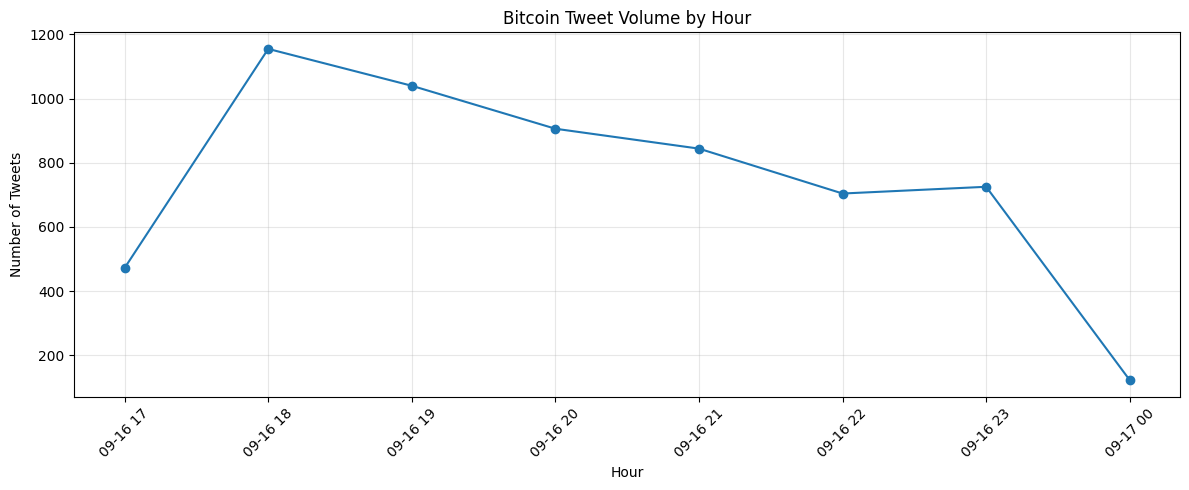

In [ ]:
# Plot hourly tweet volume.
plt.figure(figsize=(12, 5))
plt.plot(hourly_volume.index, hourly_volume.values, marker="o")
plt.title("Bitcoin Tweet Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The graph shows how Bitcoin tweet activity changes from hour to hour. Higher points indicate hours with more tweets, while lower points indicate less activity.

The peak hour is reported above to support the visual finding. Since the dataset covers only a short period, these results describe activity within the observed sample rather than a long-term Bitcoin trend.


###3.2 Word Cloud of Meaningful Words

In [ ]:
# Install the wordcloud library
!pip install -q wordcloud

In [ ]:
from wordcloud import WordCloud

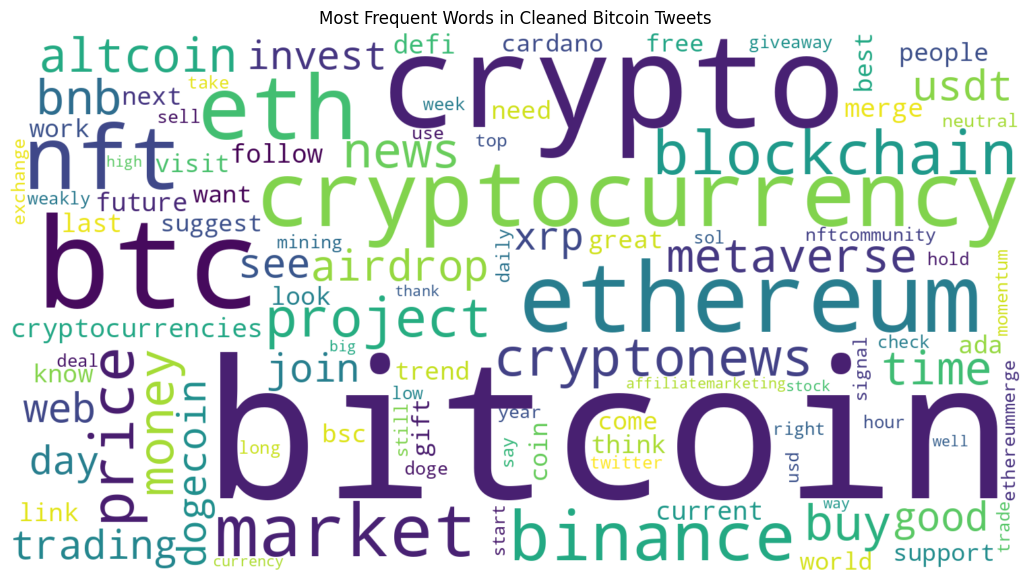

,word,frequency
0,bitcoin,6213
1,crypto,2058
2,btc,1995
3,ethereum,1095
4,cryptocurrency,1031
5,eth,978
6,market,629
7,nft,600
8,binance,542
9,blockchain,506


In [ ]:
# Combine the cleaned tweets into one corpus.
all_clean_text = " ".join(clean_df["clean_text"].dropna())

wordcloud = WordCloud(
    width=1500,
    height=800,
    background_color="white",
    max_words=100,
    collocations=False,
    random_state=42
).generate(all_clean_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Cleaned Bitcoin Tweets")
plt.show()

# Show the most frequent words numerically as supporting evidence.
word_counts = pd.Series(all_clean_text.split()).value_counts().head(15)
display(word_counts.rename_axis("word").reset_index(name="frequency"))


The word cloud provides a visual overview of the most frequent terms in the cleaned corpus. The supporting frequency table gives the same result in a form that can be compared directly.

Bitcoin-related domain terms are retained because the assignment requires them to remain available for topic modelling. The word cloud is exploratory; frequent words do not automatically represent separate topics.


###3.3 Word Cloud of Hashtags



Hashtags are examined separately because they are deliberately selected by users and can provide useful clues about the subjects being discussed.

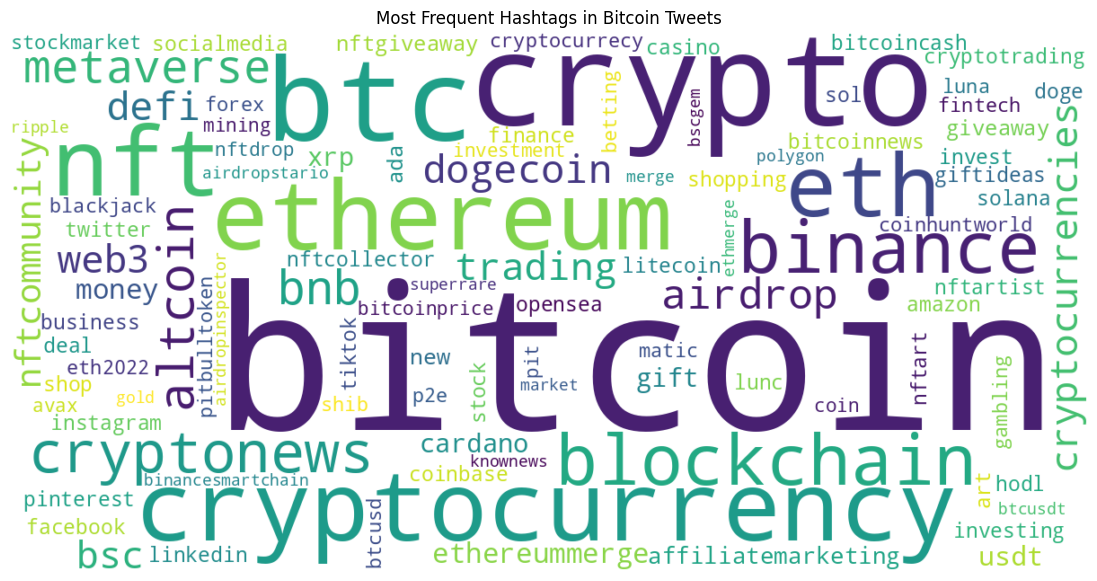

In [ ]:
# Combine retained hashtags into one string.
all_hashtags = " ".join(clean_df["hashtags_str"].dropna())

hashtag_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False,
    random_state=42
).generate(all_hashtags)

plt.figure(figsize=(14, 7))
plt.imshow(hashtag_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Hashtags in Bitcoin Tweets")
plt.show()


The hashtag word cloud shows frequently used hashtags in the cleaned corpus. Hashtags are useful exploratory indicators because users deliberately attach them to their posts.

They provide additional clues about possible themes, which are examined more directly through n-grams and topic modelling.


###3.4 Meaningful Bigrams and Trigrams

Bigrams are pairs of consecutive words and trigrams are groups of three consecutive words. They provide more context than individual word frequencies because they show which terms commonly occur together.

The most frequent combinations are used as evidence of recurring phrases in the Bitcoin discussion.


In [ ]:
# Import tools for finding common word combinations
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Count frequent two-word combinations in the cleaned corpus.
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=5
)

bigram_matrix = bigram_vectorizer.fit_transform(clean_df["clean_text"])
bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()

bigrams_df = pd.DataFrame({
    "bigram": bigram_names,
    "frequency": bigram_counts
}).sort_values("frequency", ascending=False).reset_index(drop=True)

display(bigrams_df.head(20))


,bigram,frequency
0,bitcoin btc,409
1,crypto bitcoin,393
2,btc bitcoin,379
3,bitcoin ethereum,272
4,bitcoin crypto,259
5,btc eth,222
6,crypto cryptocurrency,189
7,bitcoin cryptocurrency,160
8,bitcoin eth,153
9,bitcoin market,129


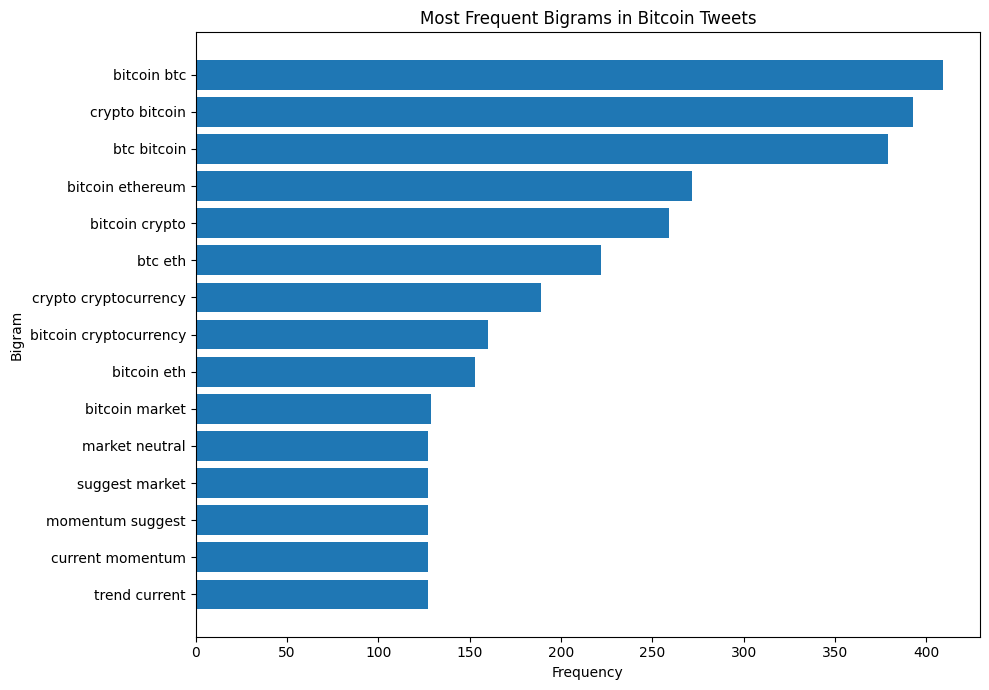

In [ ]:
# Plot the 15 most frequent bigrams.
top_bigrams = bigrams_df.head(15).sort_values("frequency")

plt.figure(figsize=(10, 7))
plt.barh(top_bigrams["bigram"], top_bigrams["frequency"])
plt.title("Most Frequent Bigrams in Bitcoin Tweets")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()


In [ ]:
# Count frequent three-word combinations in the cleaned corpus.
trigram_vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    min_df=5
)

trigram_matrix = trigram_vectorizer.fit_transform(clean_df["clean_text"])
trigram_names = trigram_vectorizer.get_feature_names_out()
trigram_counts = np.asarray(trigram_matrix.sum(axis=0)).ravel()

trigrams_df = pd.DataFrame({
    "trigram": trigram_names,
    "frequency": trigram_counts
}).sort_values("frequency", ascending=False).reset_index(drop=True)

display(trigrams_df.head(20))


,trigram,frequency
0,current momentum suggest,127
1,suggest market neutral,127
2,trend current momentum,127
3,momentum suggest market,127
4,bitcoin market weakly,120
5,weakly trend current,120
6,market weakly trend,120
7,twitter facebook instagram,62
8,crypto bitcoin cryptocurrency,62
9,btc ethereum blockchain,58


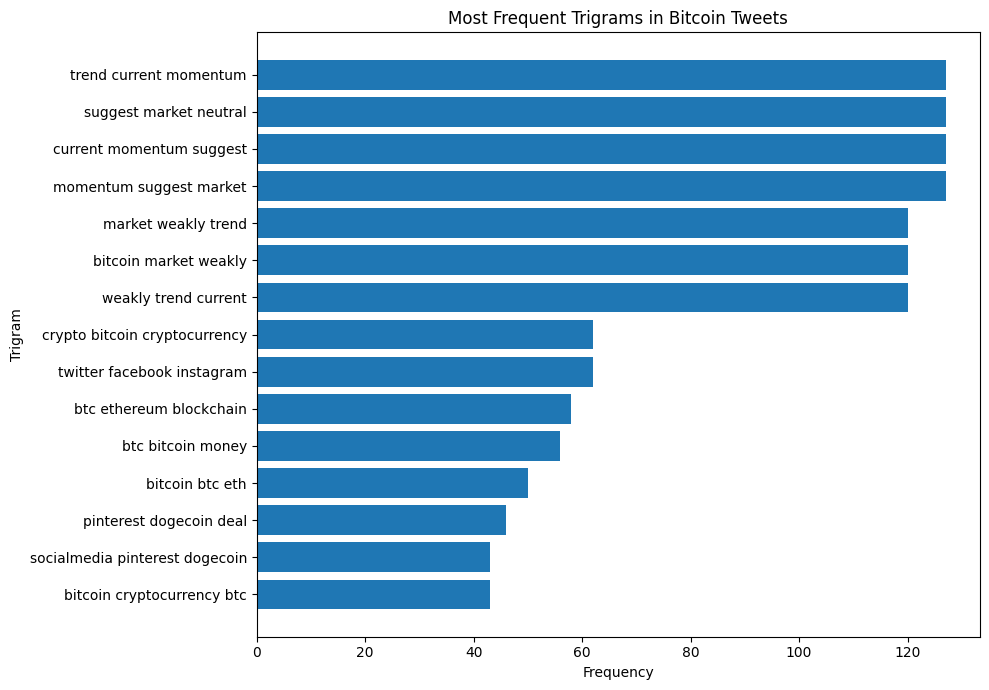

In [ ]:
# Plot the 15 most frequent trigrams.
top_trigrams = trigrams_df.head(15).sort_values("frequency")

plt.figure(figsize=(10, 7))
plt.barh(top_trigrams["trigram"], top_trigrams["frequency"])
plt.title("Most Frequent Trigrams in Bitcoin Tweets")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.tight_layout()
plt.show()


###3.5 Interpretation of Bigrams and Trigrams

The n-gram results show recurring phrases in the cleaned Bitcoin discussion.

**1. “bitcoin market”**

This phrase points to discussion linking Bitcoin with market conditions and trading activity. It provides evidence that market-related discussion was part of the observed corpus.

**2. “btc ethereum blockchain”**

This phrase connects Bitcoin with Ethereum and blockchain terminology, suggesting that some discussion was broader than Bitcoin alone and included comparisons or references to the wider cryptocurrency ecosystem.

These examples are descriptive evidence from the corpus; they do not by themselves establish complete topics. The topic models in Part 5 are used to identify broader themes.


### 3.6 Additional Visualisation

An additional visualisation examines tweet engagement. Likes and retweets are highly skewed, so a log-transformed view is used to make both low- and high-engagement tweets easier to compare.


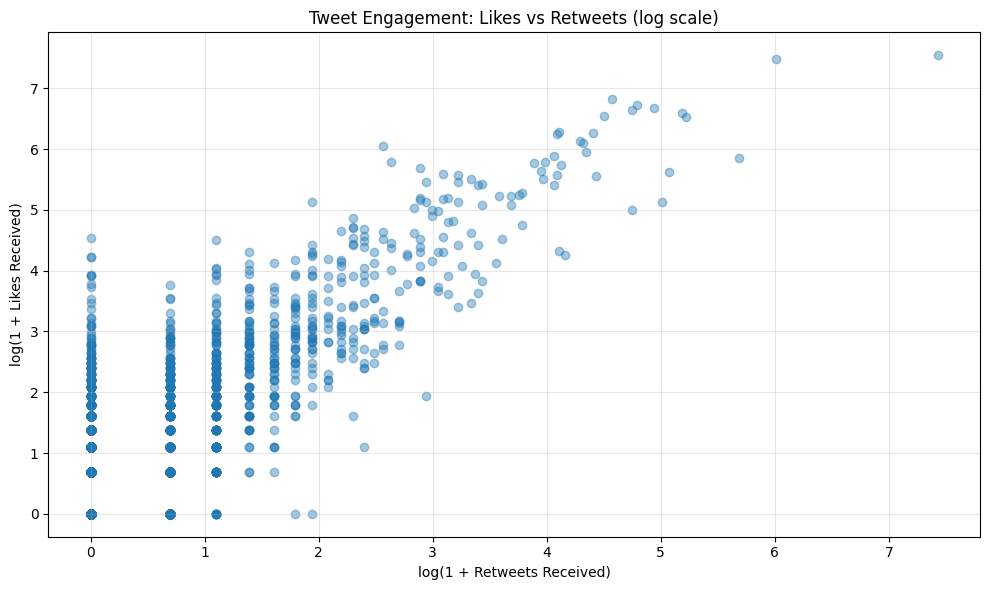

In [ ]:
# Examine engagement while reducing the effect of extreme values.
engagement_df = clean_df[["likes_received", "retweets_received"]].dropna().copy()

engagement_df["likes_log"] = np.log1p(engagement_df["likes_received"].clip(lower=0))
engagement_df["retweets_log"] = np.log1p(engagement_df["retweets_received"].clip(lower=0))

plt.figure(figsize=(10, 6))
plt.scatter(
    engagement_df["retweets_log"],
    engagement_df["likes_log"],
    alpha=0.4
)
plt.title("Tweet Engagement: Likes vs Retweets (log scale)")
plt.xlabel("log(1 + Retweets Received)")
plt.ylabel("log(1 + Likes Received)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The engagement plot shows that most tweets receive relatively low engagement, while a smaller number receive substantially more likes or retweets.

The log scale makes the distribution easier to compare without allowing a few highly engaged tweets to dominate the visualisation. This provides additional context for the text analysis.


## Part 4: Text Representation

The cleaned corpus is converted into numerical representations required by the topic models.

- **CountVectorizer** creates word-count features for **LDA**.
- **TF-IDF** creates weighted features for **NMF**.

The same cleaned corpus and comparable document-frequency limits are used for both representations.


###4.1 CountVectorizer for LDA

CountVectorizer converts the cleaned tweets into a document-term matrix. Each row represents a tweet and each column represents a vocabulary term; the values are word counts.

This count-based representation is used as the input for LDA.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Count representation for LDA.
# min_df=2 removes terms appearing in only one tweet.
# max_df=0.95 excludes terms appearing in almost every tweet.
# Domain terms are retained because they were protected during preprocessing.
count_vectorizer = CountVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1),
    lowercase=False
)

dtm_count = count_vectorizer.fit_transform(clean_df["clean_text"])

print("CountVectorizer matrix shape:", dtm_count.shape)
print("Vocabulary size:", len(count_vectorizer.get_feature_names_out()))


CountVectorizer matrix shape: (5968, 4393)
Vocabulary size: 4393


In [ ]:
count_features = count_vectorizer.get_feature_names_out()

print("First 30 vocabulary terms:")
print(count_features[:30])

# Confirm that the main protected Bitcoin terms remain available.
protected_terms = ["bitcoin", "btc", "bullish", "bearish", "mining", "trading", "price", "volatility"]
protected_check = pd.DataFrame({
    "term": protected_terms,
    "in_vocabulary": [term in count_vectorizer.vocabulary_ for term in protected_terms]
})
display(protected_check)


First 30 vocabulary terms:
['aapl' 'aave' 'abandon' 'abby' 'abc' 'ability' 'able' 'aboard'
 'absolutely' 'absorb' 'abstract' 'abstractart' 'abuse' 'abyss' 'acc'
 'accelerator' 'accept' 'access' 'accessdenied' 'accessible' 'accessory'
 'accord' 'accordingly' 'account' 'accumulate' 'accumulation' 'accuracy'
 'accurate' 'achieve' 'achieved']


,term,in_vocabulary
0,bitcoin,True
1,btc,True
2,bullish,True
3,bearish,True
4,mining,True
5,trading,True
6,price,True
7,volatility,True


In [ ]:
# Show a small sample of the document-term matrix
# Rows represent tweets and columns represent words.
count_sample = pd.DataFrame(
    dtm_count[:5, :20].toarray(),
    columns=count_features[:20]
)

display(count_sample)

,aapl,aave,abandon,abby,abc,ability,able,aboard,absolutely,absorb,abstract,abstractart,abuse,abyss,acc,accelerator,accept,access,accessdenied,accessible
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The CountVectorizer representation contains one row per modelled tweet and one column per vocabulary term. The resulting count matrix is ready for LDA in Part 5.


##4.2 TF-IDF Representation for NMF

TF-IDF (Term Frequency-Inverse Document Frequency) gives greater weight to terms that help distinguish documents and reduces the influence of terms that occur across many documents.

This representation is used as the input for NMF.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF representation for NMF.
# The same document-frequency limits are used as for CountVectorizer.
tfidf_vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1),
    lowercase=False
)

dtm_tfidf = tfidf_vectorizer.fit_transform(clean_df["clean_text"])

print("TF-IDF matrix shape:", dtm_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))


TF-IDF matrix shape: (5968, 4393)
Vocabulary size: 4393


In [ ]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("First 30 TF-IDF vocabulary terms:")
print(tfidf_features[:30])

protected_check_tfidf = pd.DataFrame({
    "term": protected_terms,
    "in_vocabulary": [term in tfidf_vectorizer.vocabulary_ for term in protected_terms]
})
display(protected_check_tfidf)


First 30 TF-IDF vocabulary terms:
['aapl' 'aave' 'abandon' 'abby' 'abc' 'ability' 'able' 'aboard'
 'absolutely' 'absorb' 'abstract' 'abstractart' 'abuse' 'abyss' 'acc'
 'accelerator' 'accept' 'access' 'accessdenied' 'accessible' 'accessory'
 'accord' 'accordingly' 'account' 'accumulate' 'accumulation' 'accuracy'
 'accurate' 'achieve' 'achieved']


,term,in_vocabulary
0,bitcoin,True
1,btc,True
2,bullish,True
3,bearish,True
4,mining,True
5,trading,True
6,price,True
7,volatility,True


In [ ]:
# Show a small sample of the TF-IDF matrix for verification.
tfidf_sample = pd.DataFrame(
    dtm_tfidf[:5, :20].toarray(),
    columns=tfidf_features[:20]
)
display(tfidf_sample)


,aapl,aave,abandon,abby,abc,ability,able,aboard,absolutely,absorb,abstract,abstractart,abuse,abyss,acc,accelerator,accept,access,accessdenied,accessible
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The TF-IDF representation converts the cleaned tweets into weighted numerical features. Terms that occur across many documents receive less weight, while terms that help distinguish tweets receive relatively more weight.

The TF-IDF matrix is ready to be used by the NMF model in Part 5.


## Part 5: Topic Modelling and Model Comparison

### AI use declaration (Part 5)
Claude (Anthropic, 2026) was used as a coding and learning assistant for this section. It helped draft the code structure for the LDA/NMF models, the coherence, diversity and stability functions, and the plain-language explanations in the markdown cells. Our group ran the code on our own data, checked the outputs, chose the model settings and final model, and wrote our own interpretation of the topics.

In this section, we train, evaluate, compare, and validate two distinct topic modelling algorithms— Latent Dirichlet Allocation (LDA) and Non-Negative Matrix Factorization (NMF)—to identify prominent discussion themes in Bitcoin tweets.

**Model Inputs**:
* **LDA**: Trained using the count-based document-term matrix from `CountVectorizer`[2].
* **NMF**: Trained using the TF-IDF matrix from `TfidfVectorizer`

**Domain Term Policy**: Core domain terms such as `bitcoin`, `btc`, `bullish`, `bearish`, `trading`, `price`, `mining`, and `volatility` are retained in accordance with project guidelines

To evaluate model performance objectively, we implement three quantitative and qualitative metrics

Topic Diversity: Quantifies the percentage of unique words across all top-$N$ keywords ($N=10$) across all topics. Scores closer to $1.0$ indicate distinct topics with minimal keyword redundancy.

NPMI Topic Coherence: Measures the co-occurrence frequency of top words within the document corpus. Scores closer to zero (less negative) indicate higher semantic consistency among top words.

Human Interpretability: A qualitative check assessing whether top-10 keywords form coherent, distinct real-world themes/issues.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score

In [ ]:
K_VALUES = [4, 5, 6, 7, 8]      # topic numbers required by the brief
SEED     = 42                   # seed for the main runs (required)
ALT_SEED = 7                    # seed for the stability re-run
TOP_N    = 10                   # keywords shown / scored per topic
DOMAIN_TERMS = ["bitcoin", "btc", "bullish", "bearish", "mining", "trading", "price", "volatility"]

def top_words(components, features, n=TOP_N):
    return [[features[i] for i in comp.argsort()[::-1][:n]] for comp in components] #finds 10 words with the highest weight

def npmi_coherence(words_per_topic, binary_dtm, vocab_index):

    n_docs = binary_dtm.shape[0]
    eps = 1e-12
    topic_scores = []
    for words in words_per_topic:
        idx = [vocab_index[w] for w in words]
        sub = binary_dtm[:, idx]
        co = (sub.T @ sub).toarray() / n_docs             # joint probabilities
        p = np.diag(co).copy()                            # marginal probabilities
        pair_scores = []
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                pij = co[i, j]
                pmi = np.log((pij + eps) / (p[i] * p[j] + eps))
                pair_scores.append(np.clip(pmi / (-np.log(pij + eps)), -1, 1))
        topic_scores.append(np.mean(pair_scores))
    return float(np.mean(topic_scores)), topic_scores

def topic_diversity(words_per_topic):

    flat = [w for ws in words_per_topic for w in ws]
    return len(set(flat)) / len(flat)

def mean_jaccard_overlap(words_per_topic):
    sets = [set(w) for w in words_per_topic]
    pairs = [(a & b).__len__() / (a | b).__len__() for i, a in enumerate(sets) for b in sets[i + 1:]]
    return float(np.mean(pairs))

def fit_lda(X, k, seed):
    m = LatentDirichletAllocation(n_components=k, learning_method="batch", max_iter=40,
                                  doc_topic_prior=0.1, topic_word_prior=0.1,
                                  random_state=seed, n_jobs=-1)
    W = m.fit_transform(X)
    return m, W / W.sum(axis=1, keepdims=True)

def fit_nmf(X, k, seed):
    m = NMF(n_components=k, init="random", random_state=seed, max_iter=500, tol=1e-4)
    W = m.fit_transform(X)
    row = W.sum(axis=1, keepdims=True); row[row == 0] = 1
    return m, W / row

## 5.2 Vocabulary decision

Very frequent domain terms were not removed by default. We measured how widespread each term was, compared the models with and without a document-frequency ceiling, and then decided. Any exclusion applies only to the model vocabulary. The cleaned text, word clouds, n-grams and topic_assignments.csv keep every term, and the other protected terms were never excluded.

In [ ]:
MIN_MODEL_TERMS = 2
def build_matrices(max_df):
    cv = CountVectorizer(min_df=2, max_df=max_df, ngram_range=(1, 1), lowercase=False)
    tv = TfidfVectorizer(min_df=2, max_df=max_df, ngram_range=(1, 1), lowercase=False)
    Xc = cv.fit_transform(clean_df["clean_text"]); Xt = tv.fit_transform(clean_df["clean_text"])
    assert list(cv.get_feature_names_out()) == list(tv.get_feature_names_out())
    return cv, tv, Xc, Xt

doc_freq = pd.Series(np.asarray((dtm_count > 0).mean(axis=0)).ravel(), index=count_features).sort_values(ascending=False)
print("Share of tweets containing each of the 12 most widespread terms:")
display(doc_freq.head(12).round(3).to_frame("share_of_tweets"))

def quick_check(Xc, feats, label, k=6):
    B = (Xc > 0).astype(np.float32).tocsr(); vi = {w: i for i, w in enumerate(feats)}
    m, _ = fit_lda(Xc, k, SEED); tw = top_words(m.components_, feats)
    coh, _ = npmi_coherence(tw, B, vi)
    return {"vocabulary": label, "terms_in_vocab": len(feats), "topics_containing_bitcoin": sum("bitcoin" in t for t in tw),
            "diversity": round(topic_diversity(tw), 3), "npmi": round(coh, 3)}

CAP = 0.50          # terms present in more than 50% of tweets are left out of the MODEL vocabulary only
cv_cap, tv_cap, Xc_cap, Xt_cap = build_matrices(CAP)
removed_by_cap = sorted(set(count_features) - set(cv_cap.get_feature_names_out()))
print("Terms removed from the model vocabulary by the cap:", removed_by_cap)
display(pd.DataFrame([quick_check(dtm_count, count_features, f"Part 4 (max_df=0.95)"),
                      quick_check(Xc_cap, cv_cap.get_feature_names_out(), f"capped (max_df={CAP})")]))

USE_CAP = True
if USE_CAP: count_vectorizer_m, tfidf_vectorizer_m, X_count_all, X_tfidf_all = cv_cap, tv_cap, Xc_cap, Xt_cap
else:       count_vectorizer_m, tfidf_vectorizer_m, X_count_all, X_tfidf_all = count_vectorizer, tfidf_vectorizer, dtm_count, dtm_tfidf

keep = X_count_all.getnnz(axis=1) >= MIN_MODEL_TERMS
modelled_df = clean_df.loc[keep].reset_index(drop=True)
X_count, X_tfidf = X_count_all[keep], X_tfidf_all[keep]
features = count_vectorizer_m.get_feature_names_out()
vocab_index = {w: i for i, w in enumerate(features)}
X_binary = (X_count > 0).astype(np.float32).tocsr()          # shared reference matrix for coherence
print(f"Modelled tweets: {X_count.shape[0]:,} of {len(clean_df):,} cleaned tweets (dropped {int((~keep).sum())} with <{MIN_MODEL_TERMS} model terms)")
print(f"Vocabulary: {len(features):,} terms")

Share of tweets containing each of the 12 most widespread terms:


,share_of_tweets
bitcoin,0.916
crypto,0.291
btc,0.276
ethereum,0.169
cryptocurrency,0.159
eth,0.153
nft,0.087
binance,0.086
blockchain,0.078
market,0.077


Terms removed from the model vocabulary by the cap: ['bitcoin']


,vocabulary,terms_in_vocab,topics_containing_bitcoin,diversity,npmi
0,Part 4 (max_df=0.95),4393,6,0.65,0.128
1,capped (max_df=0.5),4392,0,0.80,0.110


Modelled tweets: 5,910 of 5,968 cleaned tweets (dropped 58 with <2 model terms)
Vocabulary: 4,392 terms


## 5.3 Train LDA and NMF for k = 4 to 8

In [ ]:
import time

results = {}
for method, fit, X in [("LDA", fit_lda, X_count), ("NMF", fit_nmf, X_tfidf)]:
    for k in K_VALUES:
        t0 = time.time(); model, W = fit(X, k, SEED); secs = time.time() - t0
        tw = top_words(model.components_, features)
        coh, coh_topics = npmi_coherence(tw, X_binary, vocab_index)
        shares = np.bincount(W.argmax(axis=1), minlength=k) / len(W)
        results[(method, k)] = dict(model=model, W=W, words=tw, coh_topics=coh_topics)
        results[(method, k)].update(
            method=method, k=k, coherence_npmi=coh, diversity=topic_diversity(tw),
            jaccard_overlap=mean_jaccard_overlap(tw), min_share=shares.min(), max_share=shares.max(),
            fit_stat=(model.perplexity(X) if method == "LDA" else model.reconstruction_err_), seconds=secs)
        print(f"{method} k={k}: coherence={coh:.3f}  diversity={topic_diversity(tw):.2f}  ({secs:.1f}s)")

LDA k=4: coherence=0.109  diversity=0.85  (32.7s)
LDA k=5: coherence=0.079  diversity=0.76  (37.5s)
LDA k=6: coherence=0.168  diversity=0.80  (33.2s)
LDA k=7: coherence=0.071  diversity=0.79  (36.2s)
LDA k=8: coherence=0.096  diversity=0.74  (38.2s)
NMF k=4: coherence=0.497  diversity=1.00  (0.1s)
NMF k=5: coherence=0.519  diversity=0.98  (0.1s)
NMF k=6: coherence=0.458  diversity=0.95  (0.2s)
NMF k=7: coherence=0.431  diversity=0.96  (0.4s)
NMF k=8: coherence=0.419  diversity=0.91  (0.2s)


## 5.4 Quantitative comparison

,method,k,coherence (NPMI),diversity,mean topic overlap (Jaccard),smallest topic share,largest topic share,fit_stat,seconds
0,LDA,4,0.109,0.850,0.059,0.146,0.334,1240.980,32.692
1,LDA,5,0.079,0.760,0.100,0.111,0.313,1236.914,37.513
2,LDA,6,0.168,0.800,0.072,0.083,0.281,1225.133,33.221
3,LDA,7,0.071,0.786,0.061,0.064,0.269,1220.596,36.177
4,LDA,8,0.096,0.738,0.077,0.066,0.248,1236.077,38.235
5,NMF,4,0.497,1.000,0.000,0.040,0.675,74.836,0.062
6,NMF,5,0.519,0.980,0.005,0.038,0.664,74.603,0.080
7,NMF,6,0.458,0.950,0.011,0.035,0.395,74.329,0.199
8,NMF,7,0.431,0.957,0.008,0.035,0.288,74.109,0.370
9,NMF,8,0.419,0.912,0.015,0.034,0.259,73.913,0.182


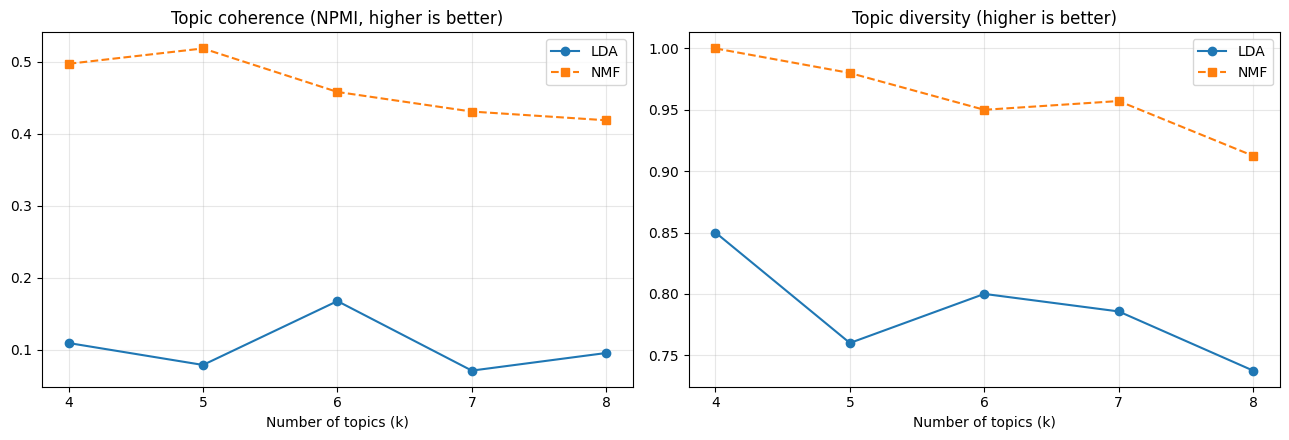

In [ ]:
summary = (pd.DataFrame([{k: v for k, v in r.items() if k not in ("model", "W", "words", "coh_topics")} for r in results.values()])
           .rename(columns={"coherence_npmi": "coherence (NPMI)", "jaccard_overlap": "mean topic overlap (Jaccard)",
                            "min_share": "smallest topic share", "max_share": "largest topic share"}))
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method, style in [("LDA", "o-"), ("NMF", "s--")]:
    s = summary[summary.method == method]
    axes[0].plot(s.k, s["coherence (NPMI)"], style, label=method)
    axes[1].plot(s.k, s["diversity"], style, label=method)
axes[0].set_title("Topic coherence (NPMI, higher is better)"); axes[1].set_title("Topic diversity (higher is better)")
for ax in axes: ax.set_xlabel("Number of topics (k)"); ax.set_xticks(K_VALUES); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

## 5.5 Human interpretabiblity

Note to members: Read the keyword lists printed below (and use show_topics("LDA", 6, n_examples=2) style calls to see example tweets). For each configuration, each group member rates every topic 1-5; enter the average in HUMAN_SCORES. Record in the report which topics were merged, split or junk (for example a topic made of one bot template).

In [ ]:
def show_topics(method, k, n_examples=1):
    r = results[(method, k)]
    top_docs = np.argsort(-r["W"], axis=0)[:n_examples]            # most representative tweets per topic
    for t in range(k):
        print(f"[{method} k={k}] Topic {t}: " + ", ".join(r["words"][t]))
        for i in top_docs[:, t]:
            print("      e.g.", modelled_df.loc[i, "text"].replace("\n", " ")[:150])
    print()

for method in ["LDA", "NMF"]:
    for k in K_VALUES:
        show_topics(method, k, n_examples=0)

[LDA k=4] Topic 0: time, money, know, people, need, buy, think, use, want, world
[LDA k=4] Topic 1: crypto, ethereum, btc, cryptocurrency, eth, nft, blockchain, binance, nfts, cryptonews
[LDA k=4] Topic 2: btc, price, crypto, market, eth, gift, cryptocurrency, buy, last, deal
[LDA k=4] Topic 3: project, market, airdrop, trend, current, visit, good, suggest, neutral, momentum

[LDA k=5] Topic 0: time, people, money, world, know, think, buy, need, say, use
[LDA k=5] Topic 1: crypto, ethereum, btc, cryptocurrency, eth, nft, blockchain, binance, nfts, cryptonews
[LDA k=5] Topic 2: btc, price, crypto, buy, market, gift, deal, eth, cryptocurrency, affiliatemarketing
[LDA k=5] Topic 3: project, market, airdrop, current, trend, visit, good, crypto, suggest, neutral
[LDA k=5] Topic 4: btc, crypto, eth, signal, price, wallet, usdt, hour, volume, need

[LDA k=6] Topic 0: time, money, people, think, know, world, buy, need, use, say
[LDA k=6] Topic 1: crypto, ethereum, btc, cryptocurrency, eth, blo



| Model | Score ||
|---|---|---|
| LDA k=4 | 2 |
| LDA k=5 | 2 |
| LDA k=6 | 3 |
| LDA k=7 | 3 |
| LDA k=8 | 2 |
| NMF k=4 | 3 |
| NMF k=5 | 5 |
| NMF k=6 | 4 |
| NMF k=7 | 4 |
| NMF k=8 | 4 |

In [ ]:
#Example scores so part 6 can be done

HUMAN_SCORES = {
    ("LDA", 4): 2, ("LDA", 5): 2, ("LDA", 6): 3, ("LDA", 7): 3, ("LDA", 8): 2,
    ("NMF", 4): 3, ("NMF", 5): 3, ("NMF", 6): 4, ("NMF", 7): 4, ("NMF", 8): 4,
}

## 5.6 Selecting the final model

Each piece of evidence (coherence, diversity and the human interpretability score) is rescaled to a 0-1 range using min-max scaling, so the three can be compared fairly. The three rescaled scores are then averaged with equal weight to give one overall score per model.

Coherence and diversity tend to favour a very small number of topics. To guard against this, any model where a single topic holds more than half of all tweets is excluded from the automatic selection, because such a model is not really separating the conversation into themes.

The automatic choice is only a starting point. If the group's reading of the topics disagrees with it, override FINAL_METHOD and FINAL_K and explain the reason in the report.

In [ ]:
cfg = summary.copy()
norm = lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0
cfg["coh_norm"] = norm(cfg["coherence (NPMI)"]); cfg["div_norm"] = norm(cfg["diversity"])
cfg["human"] = [HUMAN_SCORES.get((m, k), np.nan) for m, k in zip(cfg.method, cfg.k)]
cfg["human_norm"] = norm(cfg["human"]) if cfg["human"].notna().any() else np.nan
parts = ["coh_norm", "div_norm"] + (["human_norm"] if cfg["human"].notna().any() else [])
cfg["composite"] = cfg[parts].mean(axis=1)           # equal weight on each available form of evidence
# Guard: coherence and diversity naturally favour very small k, so a configuration where ONE topic swallows more than
# half of all tweets is not eligible for automatic selection (it is still shown in the table for discussion).
cfg["eligible"] = cfg["largest topic share"] <= 0.50
cfg.loc[~cfg["eligible"], "composite"] = np.nan
display(cfg[["method", "k", "coherence (NPMI)", "diversity", "largest topic share", "human", "composite"]].round(3))
if not cfg["human"].notna().any():
    print("No human ratings entered yet: composite uses coherence + diversity only. Add HUMAN_SCORES above and re-run.")

best_per_method = cfg.loc[cfg.groupby("method")["composite"].idxmax(), ["method", "k", "composite"]].set_index("method")
display(best_per_method.round(3))

# Override these two lines if the group's reading of the topics disagrees with the scores (and justify it in the report).
FINAL_METHOD = best_per_method["composite"].idxmax()
FINAL_K      = int(best_per_method.loc[FINAL_METHOD, "k"])
print(f"Selected model: {FINAL_METHOD} with k = {FINAL_K}")

,method,k,coherence (NPMI),diversity,largest topic share,human,composite
0,LDA,4,0.109,0.850,0.334,2,0.171
1,LDA,5,0.079,0.760,0.313,2,0.034
2,LDA,6,0.168,0.800,0.281,3,0.318
3,LDA,7,0.071,0.786,0.269,3,0.228
4,LDA,8,0.096,0.738,0.248,2,0.018
5,NMF,4,0.497,1.000,0.675,3,NaN
6,NMF,5,0.519,0.980,0.664,3,NaN
7,NMF,6,0.458,0.950,0.395,4,0.891
8,NMF,7,0.431,0.957,0.288,4,0.880
9,NMF,8,0.419,0.912,0.259,4,0.815


,k,composite
method,,
LDA,6,0.318
NMF,6,0.891


Selected model: NMF with k = 6


## 5.7 Stability check (random_state = 7)
The best k of each method is refit with a different seed. Topics are paired across seeds with the Hungarian algorithm on keyword Jaccard similarity. We report the matched Jaccard, the adjusted Rand index of the tweet-level assignments, and the two sets of keywords side by side for the qualitative comparison the brief asks for.

In [ ]:
from scipy.optimize import linear_sum_assignment

def match_topics(words_a, words_b):
    sim = np.array([[len(set(a) & set(b)) / len(set(a) | set(b)) for b in words_b] for a in words_a])
    r, c = linear_sum_assignment(-sim)
    return list(zip(r, c, sim[r, c]))

stab_rows, stab_detail = [], {}
for method in ["LDA", "NMF"]:
    k = int(best_per_method.loc[method, "k"])
    fit, X = (fit_lda, X_count) if method == "LDA" else (fit_nmf, X_tfidf)
    m7, W7 = fit(X, k, ALT_SEED)
    w7 = top_words(m7.components_, features)
    base = results[(method, k)]
    pairs = match_topics(base["words"], w7)
    coh7, _ = npmi_coherence(w7, X_binary, vocab_index)
    perm = {j: i for i, j, _ in pairs}
    ari = adjusted_rand_score(base["W"].argmax(axis=1), W7.argmax(axis=1))
    stab_rows.append({"method": method, "k": k, "mean matched Jaccard": np.mean([s for *_, s in pairs]),
                      "topics with Jaccard >= 0.30": f"{sum(s >= .30 for *_, s in pairs)}/{k}",
                      "tweet-level agreement (ARI)": ari,
                      "coherence seed 42": base["coherence_npmi"], "coherence seed 7": coh7,
                      "diversity seed 42": base["diversity"], "diversity seed 7": topic_diversity(w7)})
    stab_detail[method] = pd.DataFrame([{"seed-42 topic": i, "seed-42 keywords": ", ".join(base["words"][i][:6]),
                                         "seed-7 topic": j, "seed-7 keywords": ", ".join(w7[j][:6]), "Jaccard": round(s, 2)}
                                        for i, j, s in pairs])
    results[(method, k, "alt")] = dict(model=m7, W=W7, words=w7)

display(pd.DataFrame(stab_rows).round(3))
for method in ["LDA", "NMF"]:
    print(f"\n{method}: topic matching between seed 42 and seed 7")
    display(stab_detail[method])

,method,k,mean matched Jaccard,topics with Jaccard >= 0.30,tweet-level agreement (ARI),coherence seed 42,coherence seed 7,diversity seed 42,diversity seed 7
0,LDA,6,0.341,3/6,0.122,0.168,0.091,0.80,0.733
1,NMF,6,1.000,6/6,0.904,0.458,0.458,0.95,0.950



LDA: topic matching between seed 42 and seed 7


,seed-42 topic,seed-42 keywords,seed-7 topic,seed-7 keywords,Jaccard
0,0,"time, money, people, think, know, world",5,"crypto, btc, cryptocurrency, join, people, use",0.18
1,1,"crypto, ethereum, btc, cryptocurrency, eth, bl...",2,"crypto, eth, btc, ethereum, cryptocurrency, cr...",0.82
2,2,"btc, market, crypto, price, current, trend",3,"market, btc, crypto, eth, current, trend",0.43
3,3,"project, good, airdrop, future, great, crypto",0,"nft, crypto, ethereum, nfts, cryptocurrency, n...",0.11
4,4,"btc, crypto, signal, price, eth, last",4,"btc, price, crypto, buy, time, see",0.18
5,5,"metaverse, nft, gift, dogecoin, deal, affiliat...",1,"project, good, gift, airdrop, money, dogecoin",0.33



NMF: topic matching between seed 42 and seed 7


,seed-42 topic,seed-42 keywords,seed-7 topic,seed-7 keywords,Jaccard
0,0,"btc, price, eth, last, bnb, usd",5,"btc, price, eth, last, bnb, usd",1.0
1,1,"market, momentum, neutral, suggest, current, v...",2,"market, momentum, neutral, suggest, current, v...",1.0
2,2,"gift, deal, shop, affiliatemarketing, socialme...",1,"gift, deal, shop, affiliatemarketing, socialme...",1.0
3,3,"join, coinhuntworld, awesome, vault, location,...",3,"join, coinhuntworld, awesome, vault, location,...",1.0
4,4,"project, good, airdrop, future, great, best",4,"project, good, airdrop, future, great, best",1.0
5,5,"crypto, ethereum, cryptocurrency, eth, blockch...",0,"crypto, ethereum, cryptocurrency, eth, blockch...",1.0


## 5.8 Final model selection and discussion

**Treating the very frequent term "bitcoin".** "bitcoin" appears in 91.6% of tweets. With the original ceiling (max_df=0.95) it stayed in the model vocabulary and appeared in the top words of all 6 topics (diversity 0.65), so it said nothing about how topics differ. Capping the model vocabulary at max_df=0.5 removed only "bitcoin": it then appeared in 0 topics and diversity rose to 0.80, while coherence (NPMI) fell only slightly (0.128 to 0.110). We therefore applied the cap. This affects the model vocabulary only. "bitcoin" stays in the cleaned text, word clouds, n-grams and topic_assignments.csv, and the other protected terms (btc, price, mining, trading, etc.) were not touched.

**Quantitative evidence.** NMF scored much higher than LDA on both coherence (0.42-0.52 vs 0.07-0.17) and diversity (0.91-1.00 vs 0.74-0.85) at every k. NMF with k=4 and k=5 looked best on paper, but one topic held about two thirds of all tweets (67.5% and 66.4%), so they were excluded from automatic selection. At k=6 the largest topic holds 39.5% of tweets.

**Human interpretability.** LDA always produced a generic topic of everyday words (time, money, people, know) and several mixed topics, for example market words combined with airdrops. NMF topics were easier to name. At k=6 they are:

| Topic | Top words (short) | Our label |
|---|---|---|
| 0 | btc, price, eth, bnb, usd, signal | Coin prices and trading signals |
| 1 | market, momentum, neutral, trend, forextrading | Automated market sentiment posts |
| 2 | gift, deal, shop, affiliatemarketing | Promotions and affiliate marketing |
| 3 | join, coinhuntworld, vault, play | CoinHuntWorld game promotion |
| 4 | project, airdrop, future, bsc, usdt | Airdrops and project promotion |
| 5 | crypto, ethereum, cryptonews, nft, blockchain | General crypto and Ethereum/NFT news |

**Final choice.** We selected NMF with k=6, which had the highest combined score after min-max scaling coherence, diversity and our human interpretability ratings with equal weight, and after excluding models where one topic held over half of the tweets. The topic labels are our own interpretation, not true classes.

**Stability (seed 42 vs seed 7).** NMF k=6 was very stable: all 6 topics matched with Jaccard similarity 1.00 on their top words, coherence was identical (0.458), and tweet-level agreement was high (ARI = 0.904), so only a small share of tweets changed topic. LDA (k=6) was much less stable: mean Jaccard 0.38, only 2 of 4 topics matched well, ARI 0.155, and diversity dropped from 0.85 to 0.675. This is another reason to prefer NMF.

**Limitations.** Several NMF topics (1, 2, 3 and 4) appear to be driven by repeated, templated or promotional tweets such as trading-signal bots, affiliate marketing and game promotion. The model therefore shows what is being posted, and we cannot say it shows what people think. The high coherence and stability of NMF may partly reflect this repeated wording.

In [ ]:
final = results[(FINAL_METHOD, FINAL_K)]
final_model, final_words, final_doc_topic = final["model"], final["words"], final["W"]
print(f"Final model: {FINAL_METHOD}, k={FINAL_K}; document-topic matrix {final_doc_topic.shape} for {len(modelled_df):,} tweets")

Final model: NMF, k=6; document-topic matrix (5910, 6) for 5,910 tweets


## Part 6: Topic Analysis

This section analyses the topics produced by the selected final topic model.

## 6.1 Top 10 Keywords for Each Topic

For each topic, we display the 10 words with the highest topic weight.

In [ ]:
# Create a table where each row represents one topic
# and the columns contain its 10 most important keywords.

topic_keywords_table = pd.DataFrame(
    final_words,
    columns=[f"Keyword {i+1}" for i in range(TOP_N)]
)

topic_keywords_table.insert(
    0,
    "Topic",
    [f"Topic {t}" for t in range(FINAL_K)]
)

display(topic_keywords_table)

,Topic,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10
0,Topic 0,btc,price,eth,last,bnb,usd,ada,signal,binance,time
1,Topic 1,market,momentum,neutral,suggest,current,visit,trend,weakly,stock,forextrading
2,Topic 2,gift,deal,shop,affiliatemarketing,socialmedia,facebook,amazon,instagram,dogecoin,twitter
3,Topic 3,join,coinhuntworld,awesome,vault,location,play,find,cryptocurrency,user,blue
4,Topic 4,project,good,airdrop,future,great,best,bsc,usdt,hopefully,team
5,Topic 5,crypto,ethereum,cryptocurrency,eth,blockchain,cryptonews,nft,merge,binance,news


### Human Interpretation of the Topics

The following labels are descriptive summaries created by the researchers
after examining the dominant keywords and representative tweets.

In [ ]:
# These labels summarise the keyword patterns found by the model.
TOPIC_LABELS = {
    0: "Coin prices and trading signals",
    1: "Automated market sentiment posts",
    2: "Promotions and affiliate marketing",
    3: "CoinHuntWorld game promotion",
    4: "Airdrops and project promotion",
    5: "General crypto and Ethereum/NFT news"
}

# Check that we have supplied exactly one label for every topic.
assert set(TOPIC_LABELS.keys()) == set(range(FINAL_K))

# Add the human-readable interpretation to the keyword table.
topic_keywords_table.insert(
    1,
    "Topic label",
    [TOPIC_LABELS[t] for t in range(FINAL_K)]
)

display(topic_keywords_table)

,Topic,Topic label,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10
0,Topic 0,Coin prices and trading signals,btc,price,eth,last,bnb,usd,ada,signal,binance,time
1,Topic 1,Automated market sentiment posts,market,momentum,neutral,suggest,current,visit,trend,weakly,stock,forextrading
2,Topic 2,Promotions and affiliate marketing,gift,deal,shop,affiliatemarketing,socialmedia,facebook,amazon,instagram,dogecoin,twitter
3,Topic 3,CoinHuntWorld game promotion,join,coinhuntworld,awesome,vault,location,play,find,cryptocurrency,user,blue
4,Topic 4,Airdrops and project promotion,project,good,airdrop,future,great,best,bsc,usdt,hopefully,team
5,Topic 5,General crypto and Ethereum/NFT news,crypto,ethereum,cryptocurrency,eth,blockchain,cryptonews,nft,merge,binance,news


## 6.2 Representative Tweets for Each Topic

To illustrate what each topic represents, we identify the two tweets with the
highest topic scores for each topic.

These tweets are considered representative because the final topic model
assigns them the strongest association with that particular topic.

In [ ]:
representative_tweets = []

for topic in range(FINAL_K):

    # Get the topic scores for this topic.
    topic_scores = final_doc_topic[:, topic]

    # Find the indices of the two highest-scoring tweets.
    top_indices = np.argsort(topic_scores)[-2:][::-1]

    for rank, idx in enumerate(top_indices, start=1):

        representative_tweets.append({
            "Topic": topic,
            "Topic label": TOPIC_LABELS[topic],
            "Rank": rank,
            "Topic score": topic_scores[idx],
            "Tweet ID": modelled_df.iloc[idx]["tweet_id"],
            "Datetime": modelled_df.iloc[idx]["datetime"],
            "Tweet": modelled_df.iloc[idx]["text"]
        })

representative_tweets_df = pd.DataFrame(representative_tweets)

# Display the representative tweets.
display(
    representative_tweets_df[
        ["Topic", "Topic label", "Rank",
         "Topic score", "Tweet ID", "Datetime", "Tweet"]
    ]
)

,Topic,Topic label,Rank,Topic score,Tweet ID,Datetime,Tweet
0,0,Coin prices and trading signals,1,1.0,1570926101861638145,2022-09-17 00:02:23,Are you ready? 🔥🧨 💥\n#Bitcoin #BTC
1,0,Coin prices and trading signals,2,1.0,1570926383508951040,2022-09-17 00:03:30,"#Bitcoin $BTC Daily Summary September 16, 2022..."
2,1,Automated market sentiment posts,1,1.0,1570880459415949315,2022-09-16 21:01:01,[1h] #Bitcoin market is strongly trending down...
3,1,Automated market sentiment posts,2,1.0,1570834908670459905,2022-09-16 18:00:01,[1D] #Bitcoin market is weakly trending down c...
4,2,Promotions and affiliate marketing,1,1.0,1570926311870169090,2022-09-17 00:03:13,#linkedin #twitter #facebook #instagram #tikto...
5,2,Promotions and affiliate marketing,2,1.0,1570886793695997953,2022-09-16 21:26:11,#linkedin #twitter #facebook #instagram #surpr...
6,3,CoinHuntWorld game promotion,1,1.0,1570914813055991809,2022-09-16 23:17:32,Bitzerk found #bitcoin Resources Only) in a Us...
7,3,CoinHuntWorld game promotion,2,1.0,1570862506062774273,2022-09-16 19:49:41,Berzerker found #bitcoin in a User vault at th...
8,4,Airdrops and project promotion,1,1.0,1570925744242688000,2022-09-17 00:00:58,Good project and congratulations to the whole ...
9,4,Airdrops and project promotion,2,1.0,1570852147956416513,2022-09-16 19:08:31,This is the great project and the best project...


## 6.3 Assigning Tweets to Their Dominant Topic

Each modelled tweet has a topic score for every topic.

The dominant topic is defined as the topic with the highest score for that
tweet. This produces one dominant topic assignment for every modelled tweet.

In [ ]:
# Find the topic with the highest score for each tweet.
dominant_topic = final_doc_topic.argmax(axis=1)

# Extract the score of the dominant topic for each tweet.
dominant_topic_score = final_doc_topic.max(axis=1)

# Create a copy of the modelled dataset so that we do not
# accidentally overwrite the original modelling data.
topic_assignments = modelled_df.copy()

# Add the model-derived topic information.
topic_assignments["assigned_topic"] = dominant_topic

topic_assignments["topic_label"] = topic_assignments[
    "assigned_topic"
].map(TOPIC_LABELS)

topic_assignments["topic_score"] = dominant_topic_score

# Display a sample to verify the result.
display(
    topic_assignments[
        [
            "tweet_id",
            "datetime",
            "clean_text",
            "assigned_topic",
            "topic_label",
            "topic_score"
        ]
    ].head(10)
)

,tweet_id,datetime,clean_text,assigned_topic,topic_label,topic_score
0,1570926708165050370,2022-09-17 00:04:48,bitcoin price current price bitcoin btc crypto...,0,Coin prices and trading signals,0.471923
1,1570926701168971776,2022-09-17 00:04:46,saitama saitamawolfpack saitapro saita crypto ...,5,General crypto and Ethereum/NFT news,0.712576
2,1570926684085555201,2022-09-17 00:04:42,check tonight btc bitcoin crypto cryptocurrenc...,5,General crypto and Ethereum/NFT news,0.422944
3,1570926624119623680,2022-09-17 00:04:28,people seem forget bitcoin hit mid way back su...,0,Coin prices and trading signals,0.447478
4,1570926613864534018,2022-09-17 00:04:25,ethereum price update eth usd bitcoin btc foll...,0,Coin prices and trading signals,0.529694
5,1570926606822309891,2022-09-17 00:04:24,buy house put rest bitcoin,0,Coin prices and trading signals,0.425772
6,1570926603651411968,2022-09-17 00:04:23,recommend trade alt coin bitcoin transfer priv...,0,Coin prices and trading signals,0.653268
7,1570926590670024705,2022-09-17 00:04:20,current cardano price alert ada usd bitcoin bt...,0,Coin prices and trading signals,0.543059
8,1570926593366953987,2022-09-17 00:04:20,hello kiddy remember asset class psychological...,5,General crypto and Ethereum/NFT news,0.642063
9,1570926584319840257,2022-09-17 00:04:18,binancecoin price update bnb bnb usd bitcoin b...,0,Coin prices and trading signals,0.576587


## 6.4 Share of Tweets in Each Topic

,Topic,Topic label,Number of tweets,Share (%)
0,0,Coin prices and trading signals,1967,33.28
1,1,Automated market sentiment posts,292,4.94
2,2,Promotions and affiliate marketing,207,3.50
3,3,CoinHuntWorld game promotion,226,3.82
4,4,Airdrops and project promotion,886,14.99
5,5,General crypto and Ethereum/NFT news,2332,39.46


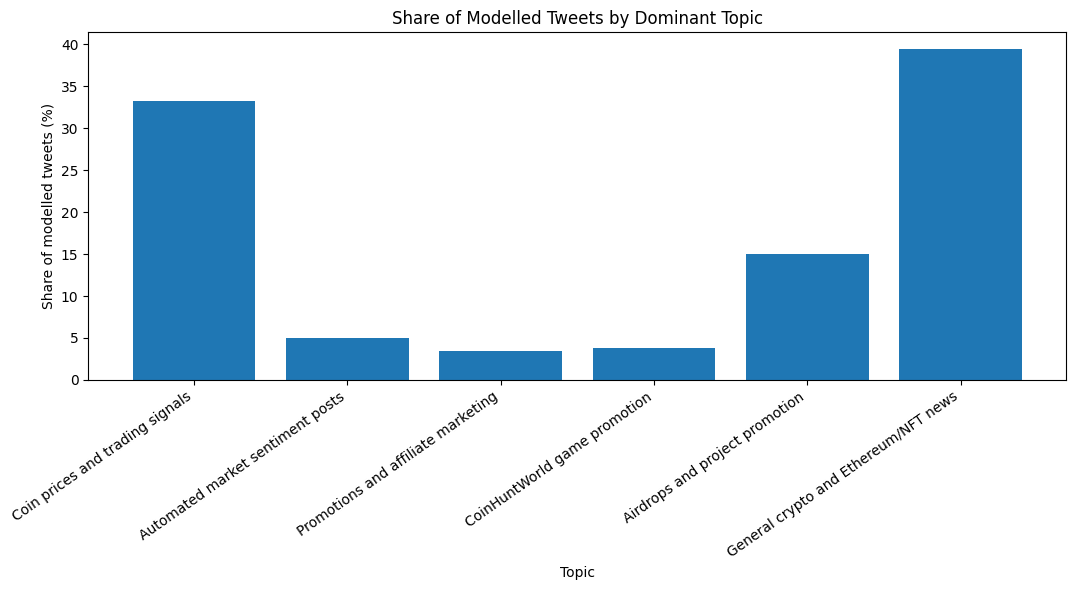

In [ ]:
# Count the number of tweets assigned to each topic.
topic_counts = (
    topic_assignments["assigned_topic"]
    .value_counts()
    .sort_index()
)

# Calculate each topic's percentage of the modelled corpus.
topic_shares = (
    topic_counts / len(topic_assignments) * 100
)

# Create a clean summary table.
topic_share_table = pd.DataFrame({
    "Topic": range(FINAL_K),
    "Topic label": [
        TOPIC_LABELS[t] for t in range(FINAL_K)
    ],
    "Number of tweets": topic_counts.values,
    "Share (%)": topic_shares.values
})

display(topic_share_table.round(2))

# VISUALISE OVERALL TOPIC PREVALENCE
plt.figure(figsize=(11, 6))

plt.bar(
    topic_share_table["Topic label"],
    topic_share_table["Share (%)"]
)

plt.xlabel("Topic")
plt.ylabel("Share of modelled tweets (%)")
plt.title("Share of Modelled Tweets by Dominant Topic")

# Rotate labels because the topic descriptions are relatively long.
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

## 6.5 Topic Prevalence by Hour

In [ ]:
# Convert the datetime column to datetime format
topic_assignments["datetime"] = pd.to_datetime(
    topic_assignments["datetime"],
    errors="coerce"
)

# Create an hourly time column
topic_assignments["hour"] = topic_assignments["datetime"].dt.floor("1h")

# Count the number of tweets for each topic in each hour
hourly_topic_counts = (
    topic_assignments
    .groupby(["hour", "assigned_topic"])
    .size()
    .unstack(fill_value=0)
)

# Make sure all 6 topics are included
hourly_topic_counts = hourly_topic_counts.reindex(
    columns=range(FINAL_K),
    fill_value=0
)

# Calculate the total number of tweets in each hour
hourly_totals = hourly_topic_counts.sum(axis=1)

# Convert topic counts into percentages
hourly_topic_share = (
    hourly_topic_counts
    .div(hourly_totals, axis=0)
    * 100
)

# Replace topic numbers with their topic labels
hourly_topic_share.columns = [
    TOPIC_LABELS[t] for t in range(FINAL_K)
]

# Display the first few rows
display(hourly_topic_share.head())

,Coin prices and trading signals,Automated market sentiment posts,Promotions and affiliate marketing,CoinHuntWorld game promotion,Airdrops and project promotion,General crypto and Ethereum/NFT news
hour,,,,,,
2022-09-16 17:00:00,31.049251,3.854390,1.284797,5.567452,18.843683,39.400428
2022-09-16 18:00:00,27.010490,13.374126,2.622378,3.496503,15.996503,37.500000
2022-09-16 19:00:00,33.720930,2.034884,3.585271,3.003876,14.922481,42.732558
2022-09-16 20:00:00,36.954087,3.471445,3.135498,3.919373,12.318029,40.201568
2022-09-16 21:00:00,34.808612,2.153110,4.545455,3.110048,15.909091,39.473684


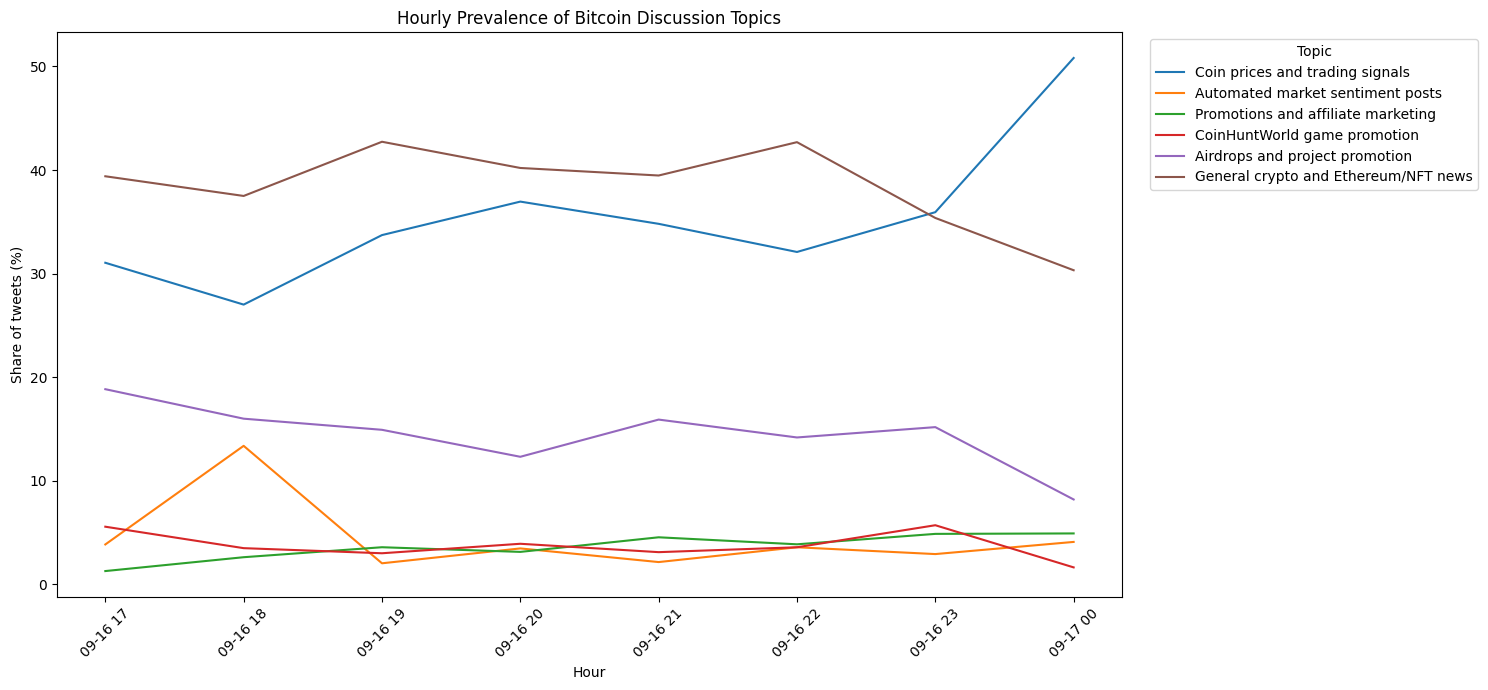

In [ ]:
# Create a line chart showing topic prevalence by hour

plt.figure(figsize=(15, 7))

for topic in hourly_topic_share.columns:
    plt.plot(
        hourly_topic_share.index,
        hourly_topic_share[topic],
        label=topic
    )

plt.xlabel("Hour")
plt.ylabel("Share of tweets (%)")
plt.title("Hourly Prevalence of Bitcoin Discussion Topics")

plt.legend(
    title="Topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The hourly topic prevalence shows how the proportion of tweets assigned to each topic changes during the observed period.

### Key Observations

- **General crypto and Ethereum/NFT news** is the most prominent topic across all five hours shown. Its share ranges from **37.50% to 42.73%**, reaching its highest level at **19:00 (42.73%)**.

- **Coin prices and trading signals** become more prominent overall. The topic increases from **31.05% at 17:00** to **34.81% at 21:00**, with its highest share occurring at **20:00 (36.95%)**.

- **Airdrops and project promotion** generally becomes less prominent. Its share decreases from **18.84% at 17:00** to **15.91% at 21:00**, reaching its lowest level at **20:00 (12.32%)**.

- **CoinHuntWorld game promotion** also shows an overall decrease, falling from **5.57% at 17:00** to **3.11% at 21:00**, although there is a small increase at 20:00.

- **Promotions and affiliate marketing** becomes more prominent overall, increasing from **1.28% at 17:00** to **4.55% at 21:00**, although its share fluctuates during the period.

- **Automated market sentiment posts** show the greatest fluctuation. The topic increases sharply from **3.85% at 17:00 to 13.37% at 18:00**, before falling to **2.03% at 19:00** and remaining around 2–3% during the following hours.

### Overall Interpretation

**General crypto and Ethereum/NFT news remains the dominant topic** in the hours shown. At the same time, **Coin prices and trading signals become relatively more prominent**, while **Airdrops and project promotion** and **CoinHuntWorld game promotion** become less prominent.

These results describe changes in the **model-assigned topic shares** over time. The changes in topic prevalence do not, by themselves, establish the reasons why the topics increased or decreased.


## 6.6 Four Evidence-Based Analytical Insights

The NMF topic model identified six model-derived themes in the Bitcoin tweet corpus.
The following insights are based on the topic keywords, topic shares, representative
tweets, and changes in topic prevalence over time.

---

### Insight 1: `General crypto and Ethereum/NFT news` is a dominant part of the discussion

**What the model shows:**  
The topic labelled **'General crypto and Ethereum/NFT news'** has the highest
prevalence across the five-hour period shown. Its share ranges from **37.50%
to 42.73%**, reaching its highest level of **42.73% at 19:00**.

**What this may mean:**  
This suggests that the Bitcoin discussion in the observed period was not limited
to Bitcoin price movements. A substantial proportion of the conversation was
also related to broader cryptocurrency developments, including Ethereum and
NFT-related topics.

---

### Insight 2: `Coin prices and trading signals` becomes more prominent

**What the model shows:**  
The **'Coin prices and trading signals'** topic increases from **31.05% at
17:00** to **34.81% at 21:00**, reaching a peak of **36.95% at 20:00**.

**What this may mean:**  
The increase suggests that price and trading-related content became relatively
more prominent during the observed period. This may indicate increased attention
to market movements or trading activity in the Bitcoin discussion, although the
topic model alone cannot establish the specific reason for the increase.

---

### Insight 3: `Airdrops and project promotion` becomes less prominent

**What the model shows:**  
The **'Airdrops and project promotion'** topic decreases from **18.84% at
17:00** to **15.91% at 21:00**, reaching its lowest observed share of
**12.32% at 20:00**.

**What this may mean:**  
This pattern suggests that promotional discussion related to airdrops and
projects became relatively less prominent compared with other topics during
the period shown. This may indicate a shift in the focus of the conversation
towards other cryptocurrency-related themes.

---

### Insight 4: `Automated market sentiment posts` show strong short-term variation

**What the model shows:**  
The **'Automated market sentiment posts'** topic changes substantially during
the observed period. Its share increases from **3.85% at 17:00** to **13.37%
at 18:00**, before falling sharply to **2.03% at 19:00** and remaining around
2–3% during the following hours.

**What this may mean:**  
The large short-term change suggests that automated sentiment-related content
was concentrated during particular periods rather than remaining consistently
prominent. This may reflect bursts of automated or sentiment-focused posting,
but the topic model does not provide enough evidence to determine the exact
cause of this fluctuation.

---

### Overall Interpretation

The topic model suggests that the Bitcoin discussion contains a
combination of **'broader cryptocurrency news', 'price and trading discussion',
'promotional content', and 'automated market sentiment'**. The relative
prominence of these themes changes over time, showing that the discussion is
not focused on a single theme throughout the observed period.

> **Important:** These findings represent **model-derived topics and their
> observed prevalence**. The interpretations describe what these patterns
> *may* indicate, rather than claiming that the topic model proves the
> underlying reasons for the changes.

### References
Anthropic. (2026). *Claude Sonnet 5.5* [Large language model]. https://claude.ai